In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
from matplotlib_venn import venn3
import pyranges as pr
import yaml
import time
from itertools import combinations
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Load gene resources

In [2]:
%%time 
# === Load and filter GTF ===
gtf_file = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
gtf = pr.read_gtf(gtf_file)

exons = gtf[gtf.Feature == "exon"].df
print(f"{exons.shape=}")
exons.head()


exons.shape=(1586950, 27)
CPU times: user 52.7 s, sys: 4.67 s, total: 57.3 s
Wall time: 57.7 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
0,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN
1,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,1,ENSE00002299440,2,NaN,NaN,ENSP00000483280.1,NaN
2,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,2,ENSE00003739295,1,NaN,NaN,ENSP00000483280.1,NaN
3,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,3,ENSE00003723764,1,NaN,NaN,ENSP00000483280.1,NaN
4,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1,NaN,1,ENSE00003736481,1,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [3]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

idf.head()

idf.shape=(110149, 11)


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [4]:
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

# Load Data

In [5]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 319 ms, sys: 403 ms, total: 723 ms
Wall time: 1.61 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

# Preprocessing

In [6]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43826 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 21062 × 69509
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'n_counts', 'n_cells'
    uns: 'subgroup_colors', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

# Isoform Table

In [7]:
%%time 
adata.X = adata.layers['counts'].copy()
rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

aggdata = rsc.get.aggregate(
    adata, 
    by='group',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(aggdata, convert_all=True,)
df = aggdata.to_df(layer='sum')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)
df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
df.head()

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
CPU times: user 245 ms, sys: 14.9 ms, total: 260 ms
Wall time: 273 ms


,transcript_name,bm_other,intial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-202,26.0,10.0,36.0,6.0,78.0,A1BG,protein_coding,retained_intron,False,NaN
1,A1BG-203,31.0,34.0,104.0,8.0,177.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
2,A1BG-204,2909.0,8093.0,10093.0,628.0,21723.0,A1BG,protein_coding,retained_intron,False,NaN
3,A1BG-AS1-202,154.0,44.0,23.0,41.0,262.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-203,2.0,22.0,16.0,0.0,40.0,A1BG-AS1,lncRNA,lncRNA,False,NaN


# add splicing events

In [8]:
fpath = "../../resources/AS_events.csv.gz"

asdf = pd.read_csv(fpath)
asdf = asdf[asdf['gene_name'].notna()]
asdf = asdf.drop(columns=['gene_id', 'transcript_id', 'gene_name'])

df = pd.merge(
    df, asdf,
    how='left',
)

print(df['event_label'].value_counts().to_string())
print()

df.head()

event_label
skipping exon                 18785
alternative 3' splice site    10244
alternative first exon         9116
alternative 5' splice site     7591
alternative last exon          2589
mutually exclusive exon        1713
retained intron                1321



,transcript_name,bm_other,intial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot,event_type,event_label
0,A1BG-202,26.0,10.0,36.0,6.0,78.0,A1BG,protein_coding,retained_intron,False,NaN,NaN,NaN
1,A1BG-203,31.0,34.0,104.0,8.0,177.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN,NaN,NaN
2,A1BG-204,2909.0,8093.0,10093.0,628.0,21723.0,A1BG,protein_coding,retained_intron,False,NaN,NaN,NaN
3,A1BG-AS1-202,154.0,44.0,23.0,41.0,262.0,A1BG-AS1,lncRNA,lncRNA,False,NaN,NaN,NaN
4,A1BG-AS1-203,2.0,22.0,16.0,0.0,40.0,A1BG-AS1,lncRNA,lncRNA,False,NaN,NaN,NaN


# Add metadata

In [9]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name')['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name')['uniprot'].transform('nunique')

# add grouped expression counts
grouped = pdf.groupby('gene_name')[['bm_other', 'intial', 'reprogram', 'target']].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in ['bm_other', 'intial', 'reprogram', 'target']:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

print(pdf[['gene_name', 'transcript_name', 'intial_pct', 'reprogram_pct', 'target_pct']].head().to_string())

  gene_name transcript_name  intial_pct  reprogram_pct  target_pct
0      A1BG        A1BG-202    0.001229       0.003518    0.009346
1      A1BG        A1BG-203    0.004178       0.010163    0.012461
2      A1BG        A1BG-204    0.994593       0.986319    0.978193
3  A1BG-AS1    A1BG-AS1-202    0.156028       0.080702    0.546667
4  A1BG-AS1    A1BG-AS1-203    0.078014       0.056140    0.000000
CPU times: user 73.6 ms, sys: 11 μs, total: 73.6 ms
Wall time: 73.3 ms


In [10]:
pdf.head()

,transcript_name,bm_other,intial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,...,n_protiens,bm_other_sum,intial_sum,reprogram_sum,target_sum,total_gene,bm_other_pct,intial_pct,reprogram_pct,target_pct
0,A1BG-202,26.0,10.0,36.0,6.0,78.0,A1BG,protein_coding,retained_intron,False,...,0,2966.0,8137.0,10233.0,642.0,21978.0,0.008766,0.001229,0.003518,0.009346
1,A1BG-203,31.0,34.0,104.0,8.0,177.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,...,0,2966.0,8137.0,10233.0,642.0,21978.0,0.010452,0.004178,0.010163,0.012461
2,A1BG-204,2909.0,8093.0,10093.0,628.0,21723.0,A1BG,protein_coding,retained_intron,False,...,0,2966.0,8137.0,10233.0,642.0,21978.0,0.980782,0.994593,0.986319,0.978193
3,A1BG-AS1-202,154.0,44.0,23.0,41.0,262.0,A1BG-AS1,lncRNA,lncRNA,False,...,0,316.0,282.0,285.0,75.0,958.0,0.487342,0.156028,0.080702,0.546667
4,A1BG-AS1-203,2.0,22.0,16.0,0.0,40.0,A1BG-AS1,lncRNA,lncRNA,False,...,0,316.0,282.0,285.0,75.0,958.0,0.006329,0.078014,0.056140,0.000000


In [11]:
pdf.columns

Index(['transcript_name', 'bm_other', 'intial', 'reprogram', 'target',
       'total_transcript', 'gene_name', 'gene_type', 'transcript_type',
       'is_tf', 'uniprot', 'event_type', 'event_label', 'n_isoforms',
       'n_protiens', 'bm_other_sum', 'intial_sum', 'reprogram_sum',
       'target_sum', 'total_gene', 'bm_other_pct', 'intial_pct',
       'reprogram_pct', 'target_pct'],
      dtype='object')

In [12]:
print(pdf[['transcript_name', 'transcript_type', 'bm_other', 'intial', 'reprogram', 'target',]].head().to_string())

  transcript_name                 transcript_type  bm_other  intial  reprogram  target
0        A1BG-202                 retained_intron      26.0    10.0       36.0     6.0
1        A1BG-203  protein_coding_CDS_not_defined      31.0    34.0      104.0     8.0
2        A1BG-204                 retained_intron    2909.0  8093.0    10093.0   628.0
3    A1BG-AS1-202                          lncRNA     154.0    44.0       23.0    41.0
4    A1BG-AS1-203                          lncRNA       2.0    22.0       16.0     0.0


In [13]:
list(pdf['transcript_type'].unique())

['retained_intron',
 'protein_coding_CDS_not_defined',
 'lncRNA',
 'protein_coding',
 'nonsense_mediated_decay',
 'non_stop_decay',
 'TEC',
 'protein_coding_LoF',
 'IG_C_gene',
 'IG_C_pseudogene',
 'IG_J_gene',
 'IG_V_gene',
 'IG_V_pseudogene',
 'TR_C_gene',
 'TR_V_gene',
 'TR_V_pseudogene',
 'TR_J_gene']

[Text(0, 0.5, '0.0'),
 Text(0, 0.6000000000000001, '0.6'),
 Text(0, 0.7000000000000001, '0.7'),
 Text(0, 0.8, '0.8'),
 Text(0, 0.9, '0.9'),
 Text(0, 1.0, '1.0'),
 Text(0, 1.1, '1.1')]

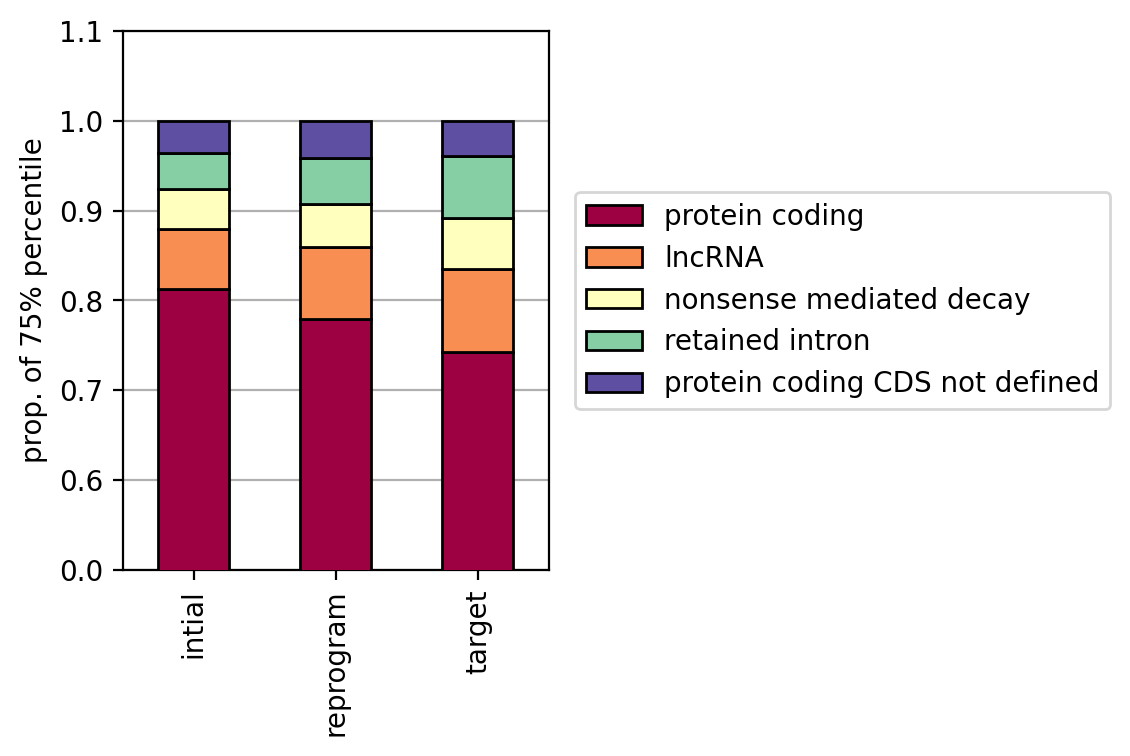

In [14]:
p = 0.75
cols = ['intial', 'reprogram', 'target']

keep = [
    'retained_intron',
    'protein_coding_CDS_not_defined',
    'lncRNA',
    'protein_coding',
    'nonsense_mediated_decay',
    # 'protein_coding_LoF',
]

proportions = {}
for col in cols:
    thresh = pdf[col].quantile(p)
    mask   = (pdf[col] > thresh) & pdf['transcript_type'].isin(keep)
    cnts   = pdf.loc[mask, 'transcript_type'].value_counts(normalize=True)
    cnts.index = cnts.index.str.replace("_", " ")
    proportions[col] = cnts

result = pd.DataFrame(proportions).fillna(0)

# pick the order you want – here, descending in “initial”
order = result['intial'].sort_values(ascending=False).index

# reindex so the stacks plot in that order
result = result.loc[order]
result = result.loc[(result != 0).any(axis=1)]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.75, 3.5
result.T.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral',
)

plt.grid(axis='y', zorder=0)
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(2.35, 0.5)
)
plt.ylabel(f'prop. of {int(p*100)}% percentile')
plt.ylim([0.5, 1.005])

ax = plt.gca()
yticks = ax.get_yticks()
yticklabels = [f"{round(t, 3)}" for t in yticks]
yticklabels[0] = 0.0    # set lowest label manually
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

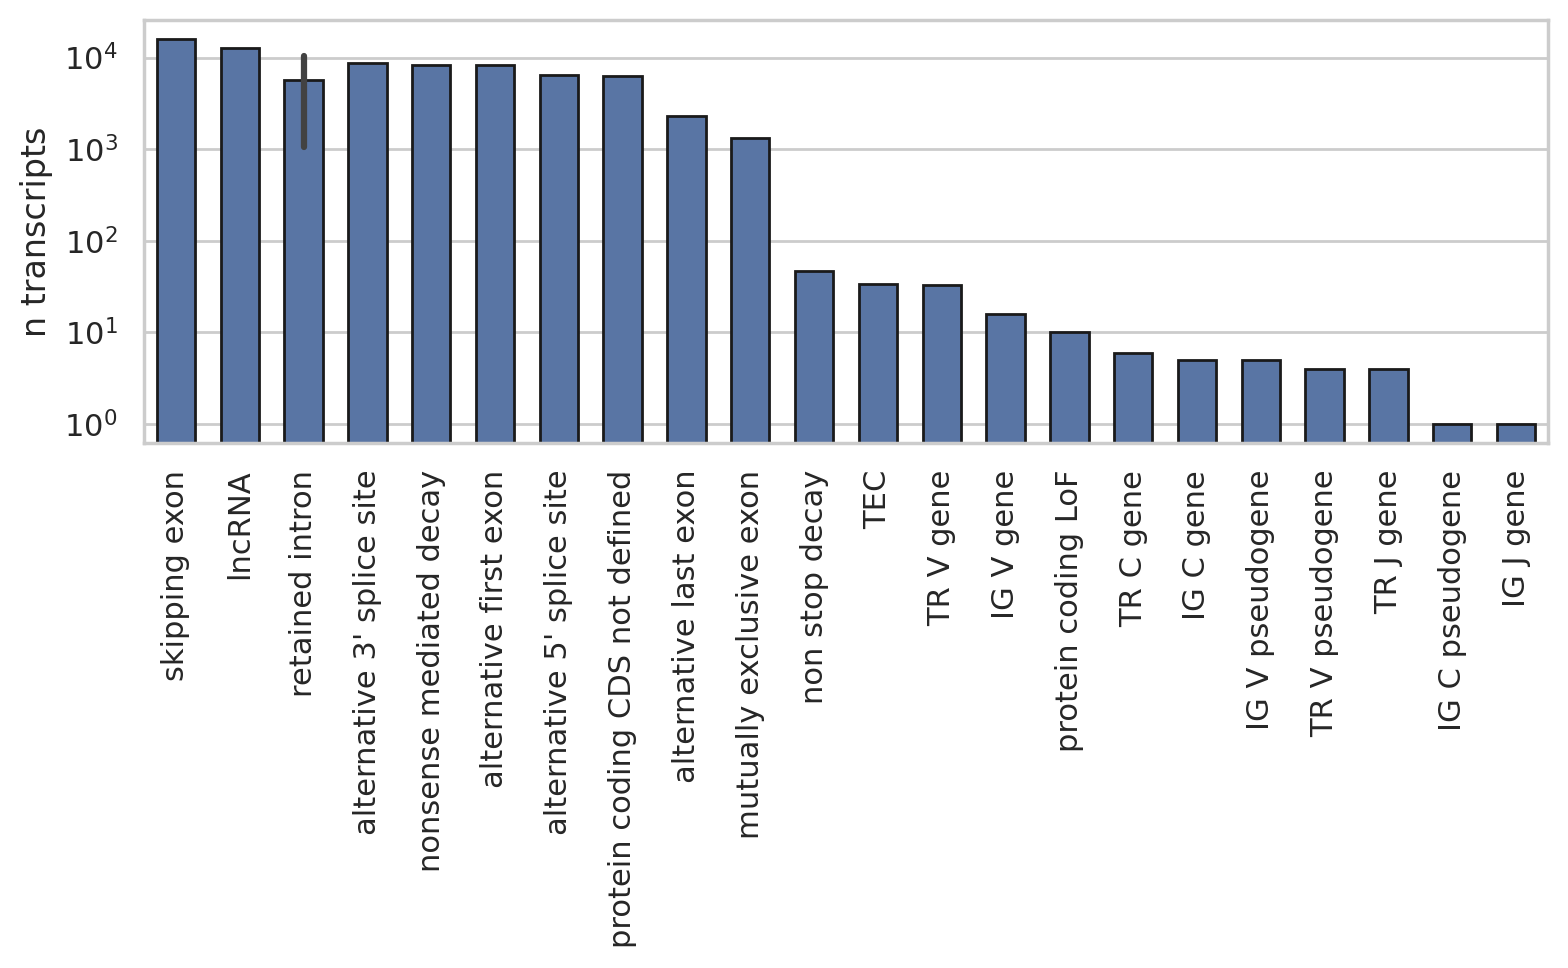

In [15]:
plot_df = pdf.copy()
plot_df['annotation'] = np.where(plot_df['transcript_type'] == 'protein_coding', plot_df['event_label'], plot_df['transcript_type'])
# print(plot_df['annotation'].value_counts().to_string())

# 1. Compute counts
counts = (
    plot_df['annotation']
    .value_counts()
    .rename_axis('annotation')
    .reset_index(name='count')
)

counts['annotation'] = counts['annotation'].astype(str)
counts['annotation'] = counts['annotation'].str.replace('_', ' ')



# 2. Set style
sns.set_theme(style='whitegrid')

# 3. Draw barplot, ordering by descending count
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=counts,
    x='annotation',
    y='count',
    order=counts.sort_values('count', ascending=False)['annotation'],
    width=0.6,
    edgecolor='k'
)

# 4. Tweak labels
ax.set_xlabel('')
ax.set_ylabel('n transcripts',)
plt.xticks(rotation=90)
plt.yscale('log')

plt.tight_layout()
plt.show()


# Dominance

In [16]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)

for col in ['intial_pct', 'reprogram_pct', 'target_pct']:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,bm_other,intial,reprogram,target,total_transcript,gene_name,gene_type,transcript_type,is_tf,...,reprogram_sum,target_sum,total_gene,bm_other_pct,intial_pct,reprogram_pct,target_pct,intial_pct_top,reprogram_pct_top,target_pct_top
0,A1BG-202,26.0,10.0,36.0,6.0,78.0,A1BG,protein_coding,retained_intron,False,...,10233.0,642.0,21978.0,0.008766,0.001229,0.003518,0.009346,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,31.0,34.0,104.0,8.0,177.0,A1BG,protein_coding,protein_coding_CDS_not_defined,False,...,10233.0,642.0,21978.0,0.010452,0.004178,0.010163,0.012461,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,2909.0,8093.0,10093.0,628.0,21723.0,A1BG,protein_coding,retained_intron,False,...,10233.0,642.0,21978.0,0.980782,0.994593,0.986319,0.978193,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,154.0,44.0,23.0,41.0,262.0,A1BG-AS1,lncRNA,lncRNA,False,...,285.0,75.0,958.0,0.487342,0.156028,0.080702,0.546667,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-202
4,A1BG-AS1-203,2.0,22.0,16.0,0.0,40.0,A1BG-AS1,lncRNA,lncRNA,False,...,285.0,75.0,958.0,0.006329,0.078014,0.056140,0.000000,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-202


<Axes: xlabel='n_isoforms', ylabel='n_protiens'>

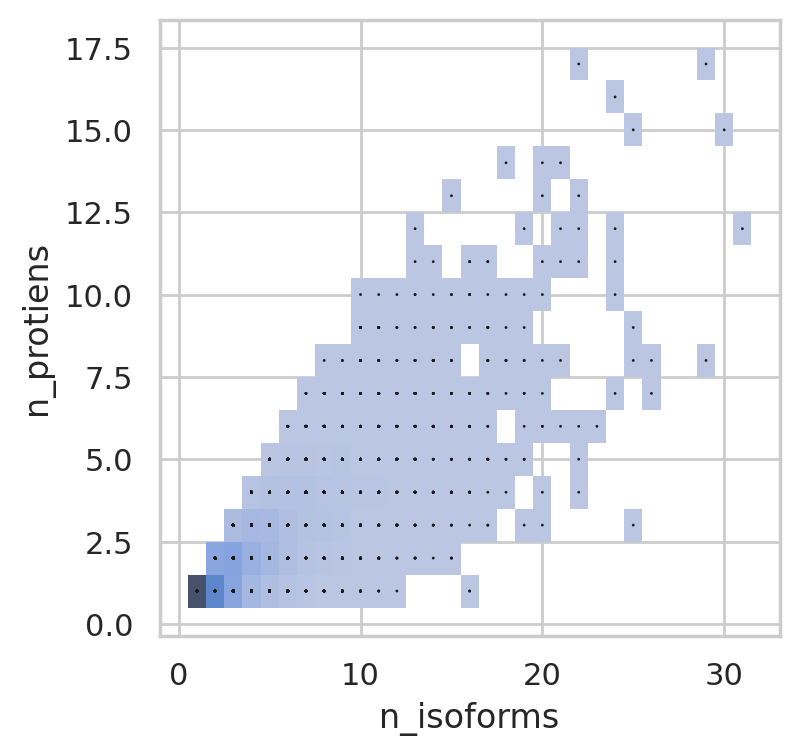

In [17]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

plot_df = pdf[['gene_name', 'n_isoforms', 'n_protiens']].drop_duplicates()
plot_df = plot_df[plot_df['n_isoforms'] > 0]
plot_df = plot_df[plot_df['n_protiens'] > 0]

sns.histplot(
    data=plot_df,
    x='n_isoforms',
    y='n_protiens',
    discrete=True,
)

sns.scatterplot(
    data=plot_df,
    x='n_isoforms',
    y='n_protiens',
    s=1,
    c='k',
    ec='none',
)

# Plot the dominant event type

In [18]:
columns = [
    'gene_name',
    'transcript_name',  
    'transcript_type', 
    'event_label', 
    'intial_pct_top',
    'reprogram_pct_top', 
    'target_pct_top',
]
qdf = pdf[columns].copy()
qdf = qdf[qdf['transcript_type'] == 'protein_coding']
qdf = qdf[['event_label', 
    'intial_pct_top',
    'reprogram_pct_top', 
    'target_pct_top',]].drop_duplicates()
print(f"{qdf.shape=}")
qdf = qdf.set_index('event_label')


unique_mask = qdf.apply(
    lambda row: row.map(row.value_counts(dropna=True)).eq(1),
    axis=1
)

# or equivalently
unique_counts = unique_mask.groupby(unique_mask.index).sum()
unique_counts.columns = [x.replace("_pct_top", "") for x in unique_counts.columns]

# Compute row sums
row_sums = unique_counts.sum(axis=1)
unique_counts = unique_counts.loc[row_sums.sort_values(ascending=False).index] # Reindex rows by descending sum

unique_counts = unique_counts.reset_index()
unique_counts = pd.melt(unique_counts, id_vars='event_label')
print(unique_counts.to_string())

qdf.shape=(19154, 4)
                   event_label   variable  value
0                skipping exon     intial    551
1       alternative first exon     intial    322
2   alternative 3' splice site     intial    298
3   alternative 5' splice site     intial    261
4        alternative last exon     intial    133
5      mutually exclusive exon     intial     71
6              retained intron     intial     54
7                skipping exon  reprogram    686
8       alternative first exon  reprogram    384
9   alternative 3' splice site  reprogram    379
10  alternative 5' splice site  reprogram    312
11       alternative last exon  reprogram    129
12     mutually exclusive exon  reprogram     94
13             retained intron  reprogram     58
14               skipping exon     target   1309
15      alternative first exon     target    758
16  alternative 3' splice site     target    711
17  alternative 5' splice site     target    573
18       alternative last exon     target    244

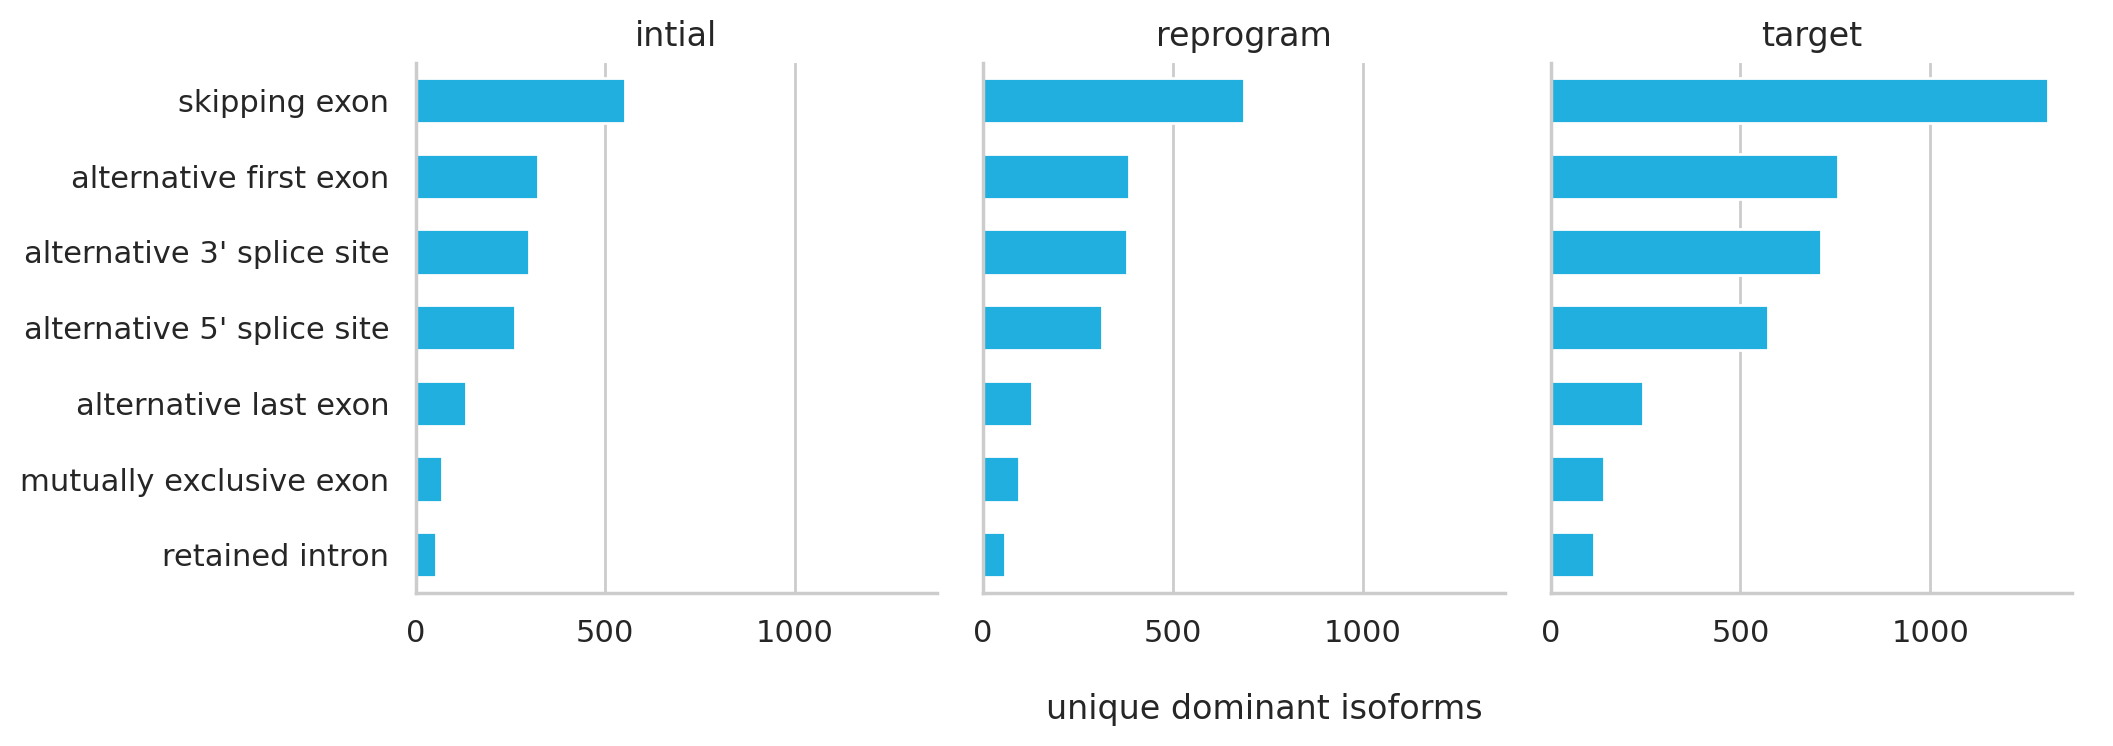

In [19]:
g = sns.catplot(
    data=unique_counts,
    x="value", 
    y="event_label", 
    col="variable",
    kind="bar",
    height=3.5,
    aspect=1.,
    color='deepskyblue',
    width=0.6,
)

g.set(xlabel=None, ylabel=None)
g.set_titles("{col_name}")

# pick the middle axis (here, 3 cols → index 1)
mid_ax = g.axes[0, 1]

# remove its default xlabel and then add a custom one
mid_ax.set_xlabel('')
pos = mid_ax.get_position()

# place text at the horizontal center of that facet, just below the plot
g.fig.text(
    pos.x0 + pos.width/2,  # x = center of middle facet
    -0.05,                  # y = a bit above the bottom of the figure
    "unique dominant isoforms",
    ha='center'
)

plt.tight_layout()

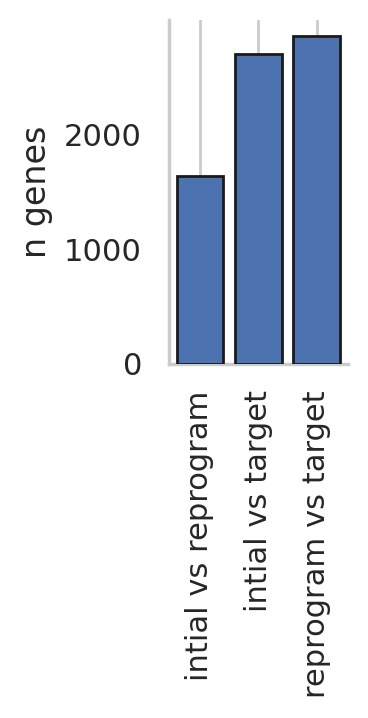

In [20]:
qdf = pdf.copy()
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
pairs = list(combinations(top_cols, 2))

# Only one row per gene to avoid duplicate counting
uniq = qdf.drop_duplicates('gene_name')

diff_counts = {}

for a, b in pairs:
    # Count unique gene_names where values differ (and neither is NaN)
    mask = (uniq[a].notna() & uniq[b].notna() & (uniq[a] != uniq[b]))
    key = f"{a.replace('_pct_top','')} vs {b.replace('_pct_top','')}"
    diff_counts[key] = mask.sum()

# Plot
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2, 3.75
plt.bar(diff_counts.keys(), diff_counts.values(), ec='k', zorder=10)
plt.ylabel("n genes")  # with differing dominant transcripts
plt.grid(axis='y')
plt.xticks(rotation=90)
plt.tight_layout()
sns.despine()
plt.show()

   intial_pct_top reprogram_pct_top target_pct_top
0        A1BG-204          A1BG-204       A1BG-204
3    A1BG-AS1-204      A1BG-AS1-209   A1BG-AS1-202
8         A2M-201           A2M-201        A2M-208
10    A2M-AS1-203       A2M-AS1-201    A2M-AS1-201
13            NaN         A2ML1-203      A2ML1-201


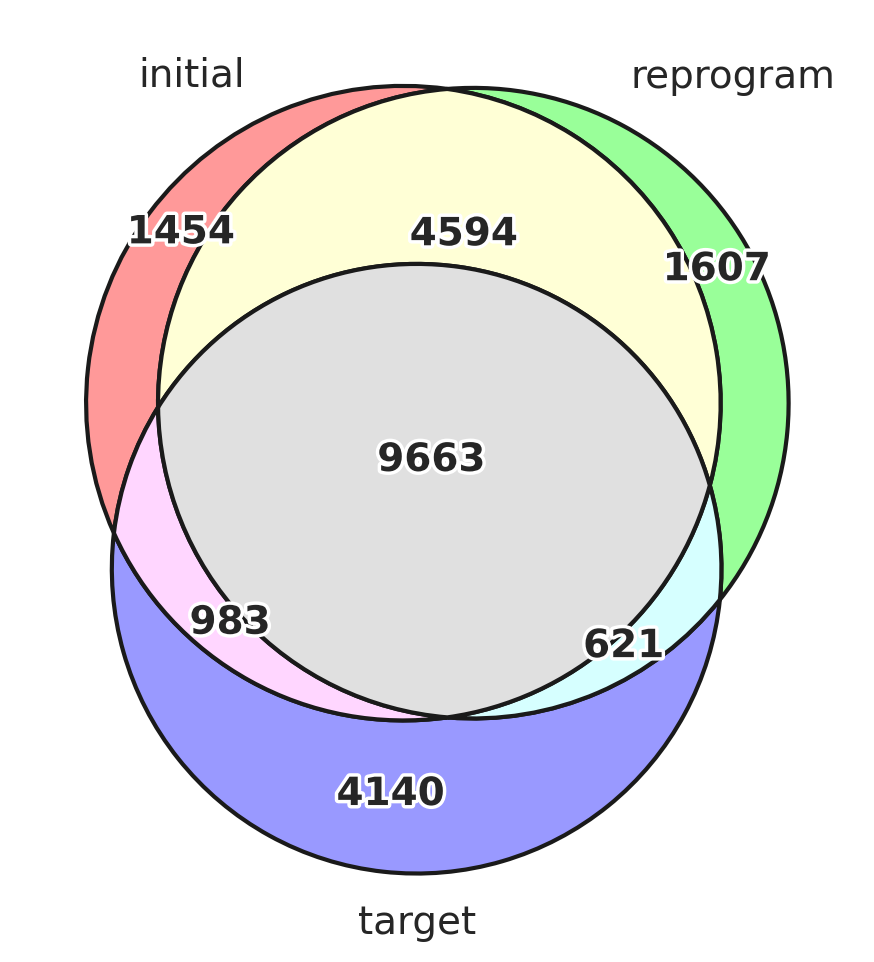

In [21]:
# Drop duplicate gene names to avoid double counting
uniq = pdf.drop_duplicates('gene_name')
print(uniq[['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']].head().to_string())

# Drop NaNs
uniq_clean = uniq.dropna(subset=['intial_pct_top', 'reprogram_pct_top', 'target_pct_top'])

# Convert each column to a set
set1 = set(uniq['intial_pct_top'].dropna())
set2 = set(uniq['reprogram_pct_top'].dropna())
set3 = set(uniq['target_pct_top'].dropna())


# Create the plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot the Venn diagram
v = venn3(
    [set1, set2, set3],
    set_labels=('initial', 'reprogram', 'target'),
    set_colors=('#FF9999','#99FF99','#9999FF'),
    ax=ax
)

# Improve appearance
for patch in v.patches:
    if patch:
        patch.set_edgecolor('k')
        patch.set_linewidth(1.5)
        patch.set_alpha(1)

# Set outline style
outline = [path_effects.Stroke(linewidth=2.5, foreground='white'),
           path_effects.Normal()]


fontsize = 14
# Style set labels
for label in v.set_labels:
    if label:
        label.set_fontsize(fontsize)

# Style subset labels with white outline
for label in v.subset_labels:
    if label:
        label.set_fontsize(fontsize)
        label.set_fontweight('bold')
        label.set_path_effects(outline)


plt.tight_layout()
plt.show()

In [22]:
"""
Top genes by expression with different dominant isoforms
"""

plot_df = pdf.copy()

plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
mask = plot_df[top_cols].nunique(axis=1, dropna=False) == 1
plot_df = plot_df[~mask]
plot_df = plot_df.sort_values(by='total_gene', ascending=False)

plot_df[['gene_name', 'transcript_name', 'intial_sum', 'reprogram_sum',
       'target_sum', 'intial_pct_top', 'reprogram_pct_top',
       'target_pct_top']].head(5)

top_genes = plot_df['gene_name'].unique().to_list()
print(top_genes[:50])

alpha = 0.01
edf = gget.enrichr(top_genes[:100], database='ontology')
edf = edf[edf['adj_p_val'] < alpha]
print(f"{edf.shape=}")

edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
print(edf[['path_name','genes']].to_string(index=False))


08:54:07 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        


['S100A6', 'CD63', 'NACA', 'COL1A2', 'COX7A2', 'COX6C', 'VIM', 'CALD1', 'CUTA', 'GAS5', 'RBIS', 'CD74', 'NUPR1', 'ENSG00000291105', 'HSBP1', 'SNRPD2', 'IGFBP5', 'CYTOR', 'SSBP1', 'DCN', 'TNFRSF11B', 'RRBP1', 'IGLL1', 'RBM3', 'S100A13', 'PARK7', 'ALDOA', 'SERPINE2', 'MRPL33', 'COX5A', 'NAA38', 'AIF1', 'PABPC1', 'HLA-DRA', 'MRPS24', 'FAM120A', 'UCHL1', 'DUT', 'PRSS23', 'DKK1', 'PCBP2', 'LOXL2', 'EIF1', 'CRABP2', 'LUM', 'CD24', 'TCEAL3', 'IGFL2-AS1', 'HLA-DRB1', 'SNHG8']
edf.shape=(4, 8)
                                                path_name                                                   genes
                collagen fibril organization (GO:0030199)                    GREM1,COL1A2,LUM,COL5A2,COL6A3,LOXL2
           supramolecular fiber organization (GO:0097435) GREM1,COL1A2,LUM,COL5A2,COL6A3,VIM,ALDOA,LYZ,RHOC,LOXL2
           extracellular matrix organization (GO:0030198)    GREM1,COL1A2,LUM,COL5A2,TIMP2,COL6A3,DCN,ELANE,LOXL2
negative regulation of programmed cell death (GO:00430

In [23]:
"""
Top genes by expression with different dominant isoform in reprogram
"""
is_tf = False

plot_df = pdf.copy()

plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]
if is_tf:
    plot_df = plot_df[plot_df['is_tf']]

mask = (plot_df['reprogram_pct_top'] != plot_df['intial_pct_top']) & (plot_df['reprogram_pct_top'] != plot_df['target_pct_top'])
plot_df = plot_df[mask]
plot_df = plot_df.sort_values(by='total_gene', ascending=False)

top_genes = plot_df['gene_name'].unique().to_list()
print(top_genes[:50])

alpha = 0.05
edf = gget.enrichr(top_genes[:50], database='ontology')
edf = edf[edf['adj_p_val'] < alpha]
print(f"{edf.shape=}")

edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
print(edf[['path_name','genes']].to_string(index=False))

08:54:08 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        


['TIMP1', 'MYL6', 'B2M', 'PTMA', 'RACK1', 'FAU', 'IFITM1', 'HSPB1', 'IFITM2', 'PFDN5', 'ACTB', 'SEC61G', 'COX7C', 'ACTG1', 'ELOB', 'COX4I1', 'CD63', 'NPM1', 'COX6B1', 'EEF1G', 'PPIB', 'PRDX1', 'MGST1', 'EEF1D', 'H2AZ1', 'H3-3B', 'ATP5MG', 'NACA', 'SSR4', 'RNASEK', 'POMP', 'IGFBP6', 'ATP5MF', 'COX6C', 'NOP10', 'HSP90AA1', 'UBB', 'GPX1', 'ATP5MJ', 'NDUFC2', 'CYBA', 'SLIRP', 'HNRNPA1', 'TSPO', 'NPC2', 'CD99', 'EIF4A1', 'RABAC1', 'RAN', 'TPM4']
edf.shape=(41, 8)
                                                                            path_name                                    genes
                                                      retina homeostasis (GO:0001895)               PRDX1,HSPB1,B2M,ACTB,ACTG1
                mitochondrial electron transport, cytochrome c to oxygen (GO:0006123)                COX4I1,COX6C,COX7C,COX6B1
                                        aerobic electron transport chain (GO:0019646)         COX4I1,NDUFC2,COX6C,COX7C,COX6B1
                  mitochondri

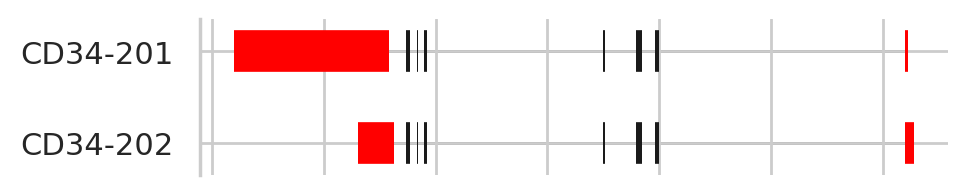

In [24]:
def plot_transcript_models(
        exons_df,
        transcript_ids,
        show_coords: bool = False,
        ax: plt.Axes | None = None,
):
    """
    Draw a schematic exon map for the supplied transcripts.

    Parameters
    ----------
    exons_df : pd.DataFrame
        Must have at least 'Start', 'End', 'transcript_name'.
    transcript_ids : list[str]
        Transcript names to plot, top → bottom.
    show_coords : bool, default False
        Whether to display genomic coordinates on the x-axis.
    ax : matplotlib.axes.Axes | None, default None
        Axis to draw on.  If None, a new figure/axis is created.

    Returns
    -------
    matplotlib.axes.Axes
        The axis the plot was drawn on.
    """
    # ── subset ──────────────────────────────────────────────────────────────────
    sel = exons_df[exons_df.transcript_name.isin(transcript_ids)]

    # count exon reuse
    coord_counts = sel.groupby(["Start", "End"]).size().to_dict()

    # ── figure / axis setup ─────────────────────────────────────────────────────
    new_fig = ax is None
    if new_fig:
        fig, ax = plt.subplots(figsize=(5, len(transcript_ids) * 0.6), dpi=200)
    else:
        fig = ax.figure

    # ── main loop ───────────────────────────────────────────────────────────────
    span_pad = 100
    for i, tx in enumerate(transcript_ids):
        tx_exons = sel[sel.transcript_name == tx]
        if tx_exons.empty:
            continue

        start, end = tx_exons.Start.min(), tx_exons.End.max()
        ax.plot([start + span_pad, end - span_pad], [i, i], lw=1,
                color="k", alpha=0.6, zorder=0)

        for row in tx_exons.itertuples():
            color = "red" if coord_counts[(row.Start, row.End)] == 1 else "k"
            ax.plot([row.Start, row.End], [i, i], lw=15, color=color,
                    solid_capstyle="butt", zorder=2)

    # ── axis cosmetics ──────────────────────────────────────────────────────────
    ax.set_yticks(range(len(transcript_ids)))
    ax.set_yticklabels(transcript_ids)
    ax.invert_yaxis()

    if not show_coords:
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        ax.set_xlabel("")
        sns.despine(ax=ax, bottom=True)
    else:
        ax.set_xlabel("coordinate")
        sns.despine(ax=ax)

    fig.tight_layout()
    if new_fig:
        plt.margins(y=0.35)
        plt.show()

    return ax

ax = plot_transcript_models(exons_df=exons,
                            transcript_ids=['CD34-201', 'CD34-202'])


In [25]:
def plot_gene_heatmap(gene, plot_df, transcript_2_uniprot, ax=None):
    """
    Plot a heatmap of transcript-level expression for a given gene,
    with a right-side axis showing UniProt IDs.

    Parameters
    ----------
    gene : str
        Gene name to plot.
    plot_df : pd.DataFrame
        Must include:
        'gene_name', 'transcript_name', 'total_transcript',
        'bm_other_pct', 'intial_pct', 'reprogram_pct', 'target_pct'.
    transcript_2_uniprot : dict
        Mapping from transcript name to UniProt ID.
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. If None, creates a new figure.
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axis the plot was drawn on.
    """

    # Filter and display transcripts
    tmp = plot_df[plot_df['gene_name'] == gene]
    print(tmp[['transcript_name', 'total_transcript']].drop_duplicates().to_string(index=False))

    # Prepare heatmap matrix
    tmp = tmp.set_index('transcript_name')
    tmp = tmp[['intial_pct', 'reprogram_pct', 'target_pct']]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]
    print(f"{tmp.shape}")

    # Figure and axis
    new_fig = ax is None
    if new_fig:
        plt.rcParams['figure.dpi'] = 200
        plt.rcParams['figure.figsize'] = max(5.5, len(tmp) / 1.2), max(3.5, len(tmp) / 1.2)
        fig, ax = plt.subplots()

    # Plot heatmap
    sns.heatmap(
        tmp,
        square=True,
        cmap='viridis',
        lw=0.5,
        linecolor='w',
        annot=True,
        fmt=".2f",
        cbar=False,
        ax=ax,
    )
    ax.set_title(gene)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

    # Right y-axis with UniProt IDs
    ax_right = ax.inset_axes([1.0, 0, 0.0001, 1.0])
    ax_right.set_yticks(np.arange(len(tmp)) + 0.5)
    ax_right.set_yticklabels([
        str(transcript_2_uniprot.get(x, "")).replace("nan", "")
        for x in tmp.index
    ])
    ax_right.set_xticks([])
    ax_right.set_ylim(ax.get_ylim())
    ax_right.tick_params(axis='y', length=0)
    ax_right.yaxis.set_label_position("right")
    ax_right.yaxis.tick_right()
    for spine in ax_right.spines.values():
        spine.set_visible(False)

    if new_fig:
        plt.tight_layout()
        plt.show()

    return ax

def get_isoforms(gene, pdf=pdf):
    return pdf[pdf['gene_name'] == gene]['transcript_name'].to_list()

In [26]:
# find genes with multiple protiens, different dominant isoforms, and different splicing events

In [27]:
list(pdf.columns)

['transcript_name',
 'bm_other',
 'intial',
 'reprogram',
 'target',
 'total_transcript',
 'gene_name',
 'gene_type',
 'transcript_type',
 'is_tf',
 'uniprot',
 'event_type',
 'event_label',
 'n_isoforms',
 'n_protiens',
 'bm_other_sum',
 'intial_sum',
 'reprogram_sum',
 'target_sum',
 'total_gene',
 'bm_other_pct',
 'intial_pct',
 'reprogram_pct',
 'target_pct',
 'intial_pct_top',
 'reprogram_pct_top',
 'target_pct_top']

In [28]:
plot_df = pdf.copy()

columns = [
    'gene_name', 
    'transcript_name',
    'transcript_type',
    'is_tf', 
    'uniprot',
    'event_label', 
    'n_isoforms',
    'n_protiens',    
    'intial_pct',
    'reprogram_pct',
    'target_pct',
    'total_gene',
]

query_col = 'reprogram_pct'   # your chosen _pct column
query_threshold = 0.65               # your cutoff
other_threshold = 0.5
total_gene = 1000

# identify all pct columns
pct_cols = [c for c in plot_df.columns if c.endswith('_pct')]
other_pct_cols = [c for c in pct_cols if c != query_col]

# 1. query > threshold
mask_query = (plot_df[query_col] > query_threshold) & (plot_df[other_pct_cols].lt(other_threshold).all(axis=1))

# 3. ≥2 unique n_protiens per gene (including NaN)
mask_prot = plot_df.groupby('gene_name')['n_protiens'] \
                   .transform(lambda x: x.nunique(dropna=False) >= 1)

# 4. n_isoforms ≥ 3 per gene
mask_iso = plot_df.groupby('gene_name')['n_isoforms'] \
                  .transform(lambda x: x.iloc[0] >= 2)

total_sum = plot_df['total_gene'] > total_gene

mask = mask_query & mask_prot & mask_iso & total_sum


filtered = plot_df[mask]
selected_genes = list(filtered['gene_name'].unique())
print(f"{len(selected_genes)=}")
print(selected_genes)

alpha = 0.05
edf = gget.enrichr(selected_genes, database='ontology')
edf = edf[edf['adj_p_val'] < alpha]
print(f"{edf.shape=}")

edf['genes'] = edf['overlapping_genes'].apply(lambda x: ",".join(x))
print(edf[['path_name','genes']].head(10).to_string(index=False))

08:54:12 - INFO - Performing Enrichr analysis using database GO_Biological_Process_2021. 
        Please note that there might be a more appropriate database for your application. 
        Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
        


len(selected_genes)=157
['ACSF3', 'AFTPH', 'AK9', 'ANKRD35', 'ARHGEF6', 'ATG13', 'ATP9A', 'BANK1', 'BTN3A1', 'C2orf81', 'C3orf14', 'C9orf43', 'CARD16', 'CCDC9B', 'CEP85L', 'CEP170', 'CERS4', 'CFAP119', 'CILK1', 'COL8A1', 'COL24A1', 'COPS2', 'COX7B', 'CREB5', 'CTDSP1', 'CTSS', 'DENND6B', 'DIP2C', 'DNASE1L1', 'DSE', 'EID1', 'ELOA-AS1', 'ELOVL5', 'ELP5', 'ENSG00000247134', 'ENSG00000250132', 'ENSG00000260877', 'ENSG00000268015', 'EPOR', 'ERAP2', 'EVI2A', 'FAM172A', 'FIRRE', 'FLI1', 'FSTL3', 'FUBP1', 'GATM', 'GBGT1', 'GBP3', 'GPANK1', 'GSG1', 'H2BC4', 'HIF1A-AS3', 'HLA-DRB1', 'HLCS', 'HNRNPA3', 'HOXB-AS1', 'HS2ST1', 'IDH1', 'IER2', 'JMJD8', 'KIF27', 'LACC1', 'LCMT1-AS1', 'LENG8', 'LHFPL2', 'LINC01237', 'LINC02021', 'LMO2', 'LNCAROD', 'LSM5', 'LTB', 'MAZ', 'MCC', 'MEAF6', 'MEF2C-AS1', 'MEGF6', 'MIR4435-2HG', 'MKNK2', 'MOB2', 'MPC1', 'MRNIP', 'MTHFR', 'MYO18A', 'NFKBID', 'NHS', 'NSUN3', 'NXT2', 'OLFML2A', 'ORAI1', 'OSBPL9', 'OTUD6B-AS1', 'PCED1B', 'PCYT1A', 'PFAS', 'PHF14', 'PLAAT3', 'PNPLA2

['ZFHX3-201', 'ZFHX3-203', 'ZFHX3-204', 'ZFHX3-205']


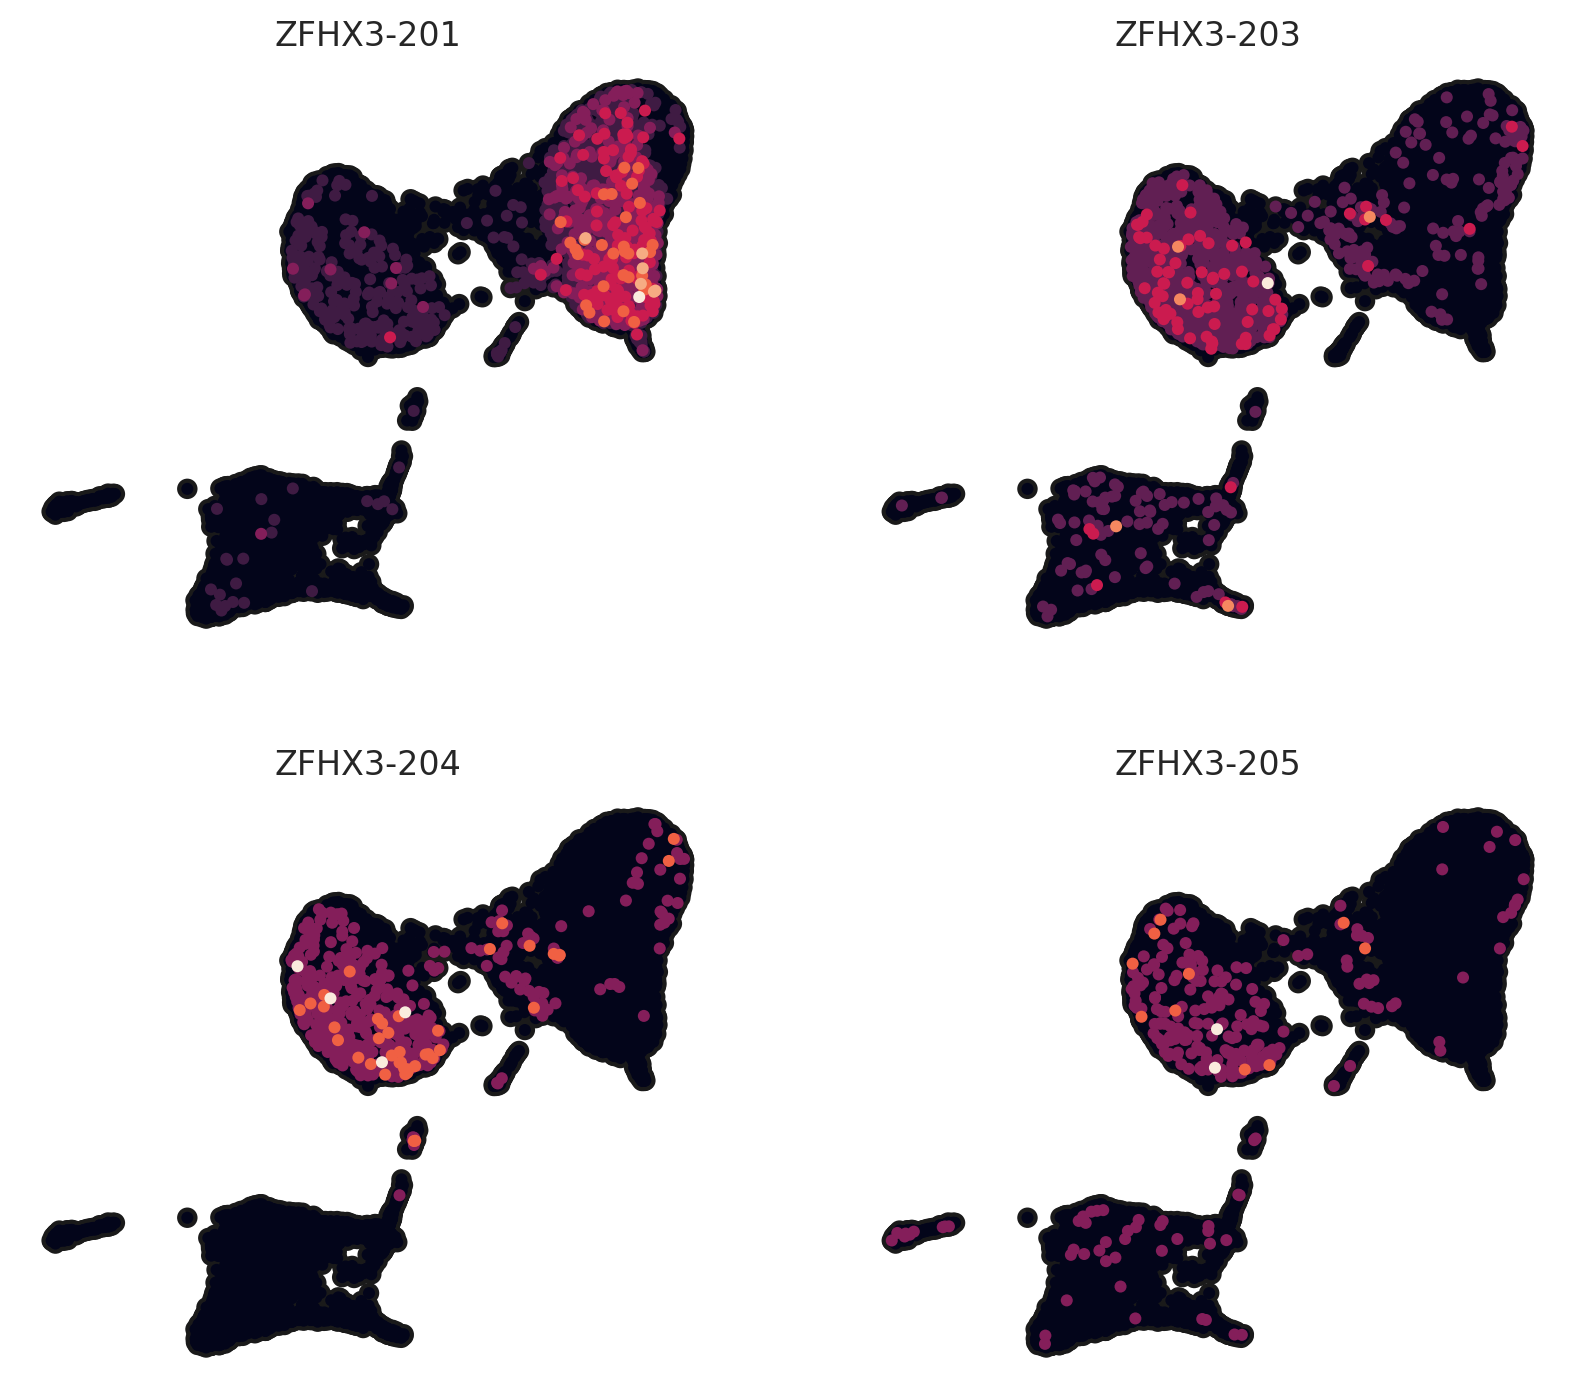

In [29]:
rsc.get.anndata_to_CPU(adata)

# query = 'CD34'
query = 'ZFHX3'
# query = 'TLE3'
tx_list = adata.var[adata.var['gene_name'] == query].index.to_list()
print(tx_list)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=2,
    sort_order=True,
    color=tx_list,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    colorbar_loc=None,
    frameon=False,
)

In [30]:
# gene_list =['CBX2', 'CREBZF', 'EID1', 'FUBP1', 'HDAC2', 'HOXA6',
#  'KDM3A', 'MXD1', 'SPEN', 'STAT1', 'SUB1', 'TCFL5',
#  'ZBTB40', 'ZCWPW2', 'ZFP41', 'ZNF177', 'ZNF431', 'ZNF484',
#  'ZNF512', 'ZNF616', 'ZNF699', 'ZNF700', 'ZNF701', 'ZNF764',
#  'ZNF781', 'LMO2', 'EPOR', 'COL8A1', 'COL24A1']

# # from the literature
#   "IKZF1", "NFIB", "MDM4", "RUNX1", "HMGA2", "NUMB", "NOTCH", "LAS1L", "ATP5F1C", "HDAC7",
#     "CPSF3", "HNRNP UL1", "TIA1", "PTBP1", "SRSF3", "RBFOX2", "SRSF2", "SRSF1", "RUNX1A", "CLK3",
#     "SRSF2", "RUNX1", "GATA2", "ETV2", "TAL1",
#     "HBA1", "HBB", "ALB", "TFRC", "GATA1", "CD34", "CD3D", "CD19", "VWF", "MPO", "PF4", "PRTN3",
#     "KLF1", "MYB", "GFI1B", "SPI1", "PBX1", "MEIS1",
# #     "U1/U2/U4/U5/U6 SNRNPS", "SRSF1-7", "SF3B1", "PRPF8", "RBM PROTEINS", "HNRNPS"

# gene_list = [
#     # 'FLI1',"NFIB", "MDM4", "RUNX1", "HMGA2", "NUMB","RBFOX2",
#     # "GATA2", "ETV2", "CD34", 'MPO', "SPI1", "PBX1", "MEIS1",  "KLF1", 
#     å
# ]

# from the 5TF binding partners
gene_list = [
    'ZFHX3', 'NFATC1', 'ABLIM1', 'KCNMA1', 'PDE4D',
    'MTSS1', 'KLHL8', 'DENND5B', 'NOS1AP', 'TSC22D1',
    'SOX5', 'ST3GAL6', 'ANXA4', 'GSN', 'SORBS2',
    'TLE3', 'SEC14L1', 'ARHGAP6', 'NRXN3', 'ZNF652',
    'RNF182', 'PFKP', 'LYPD6B', 'CABLES1', 'ESR1',
]

/tmp/ipykernel_1438625/2838668669.py:52: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig1, ax1 = plt.subplots()


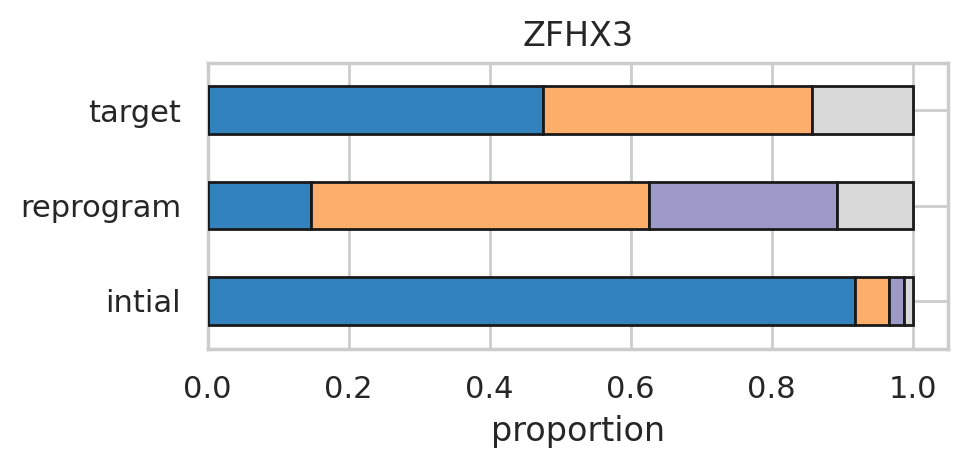

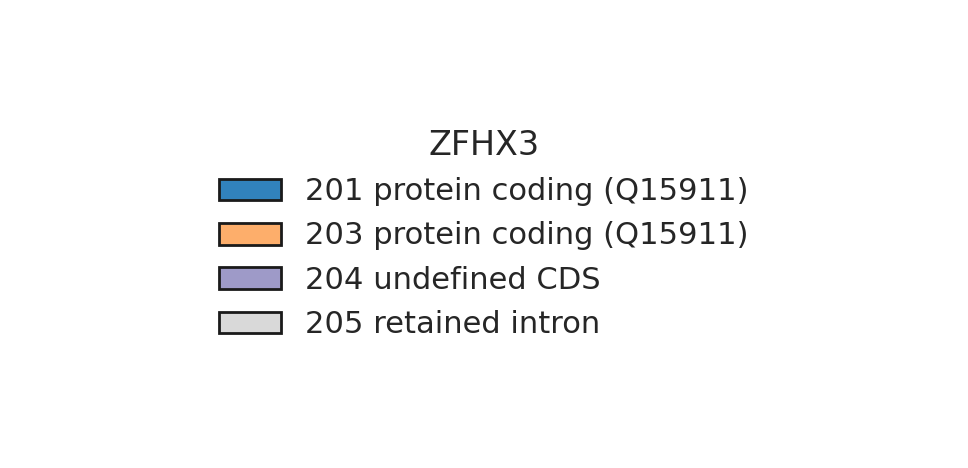

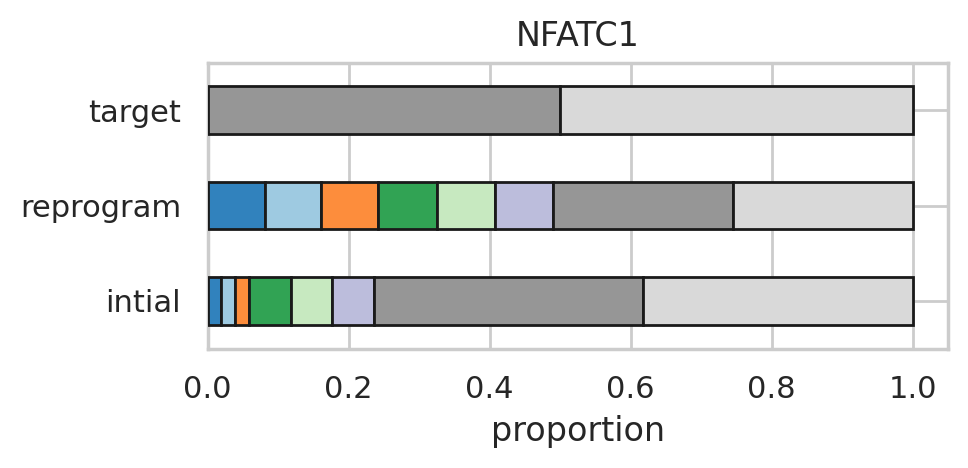

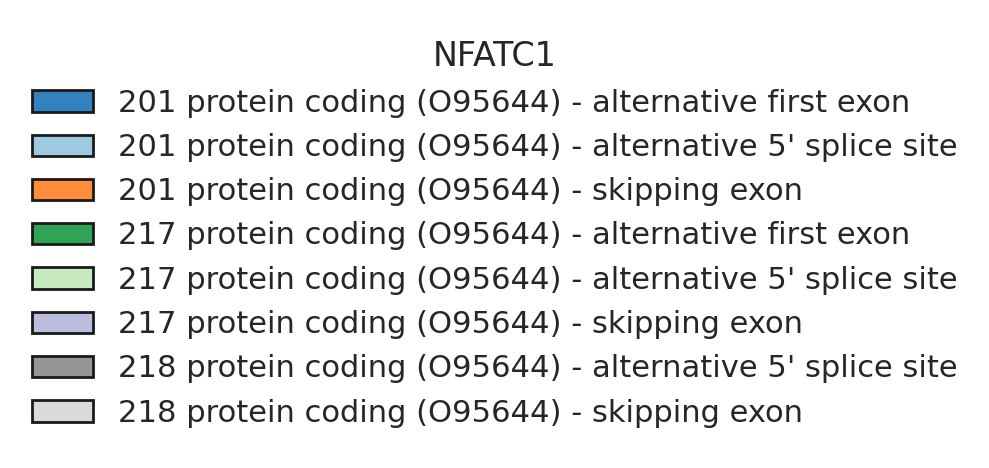

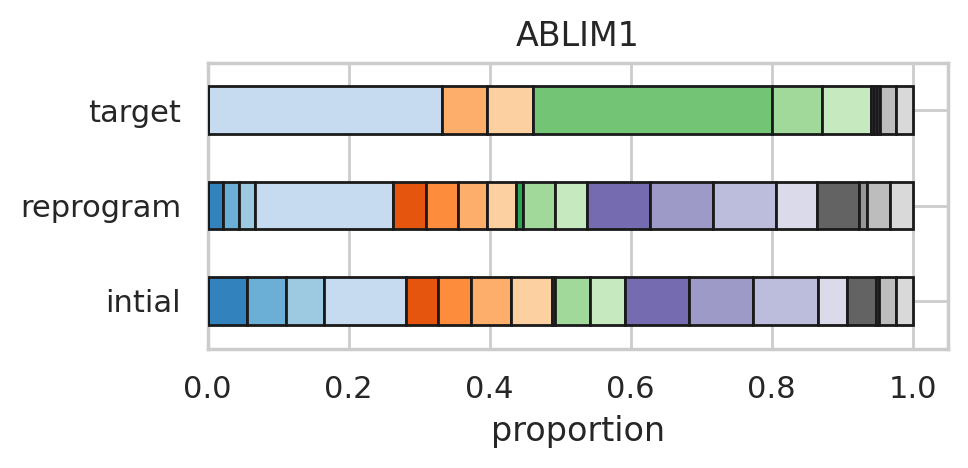

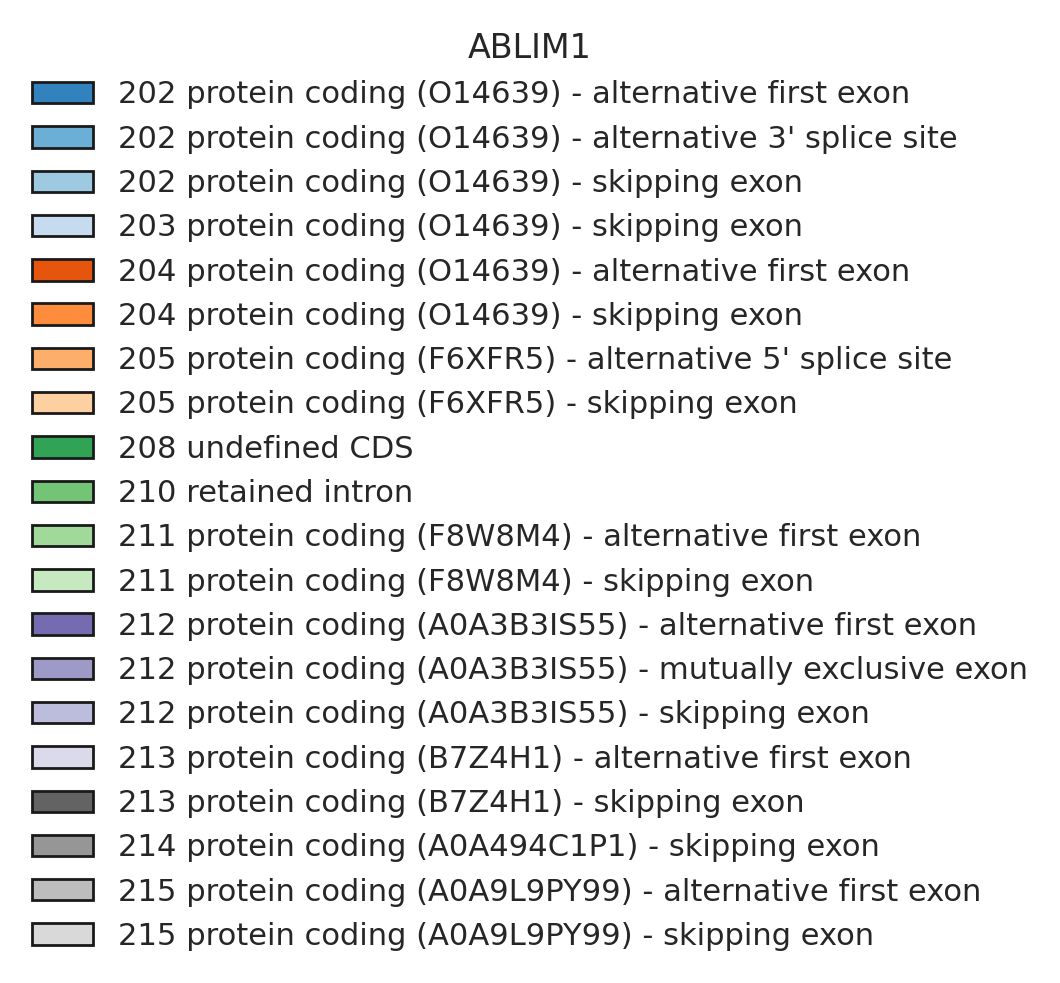

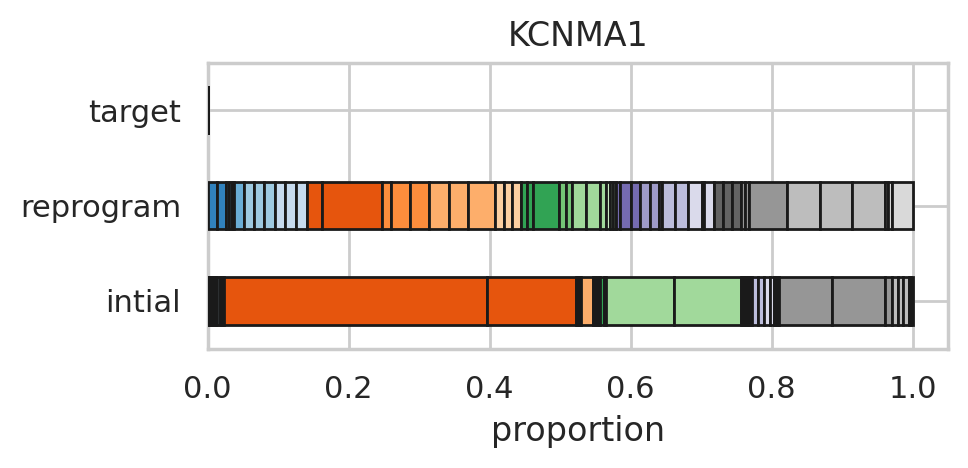

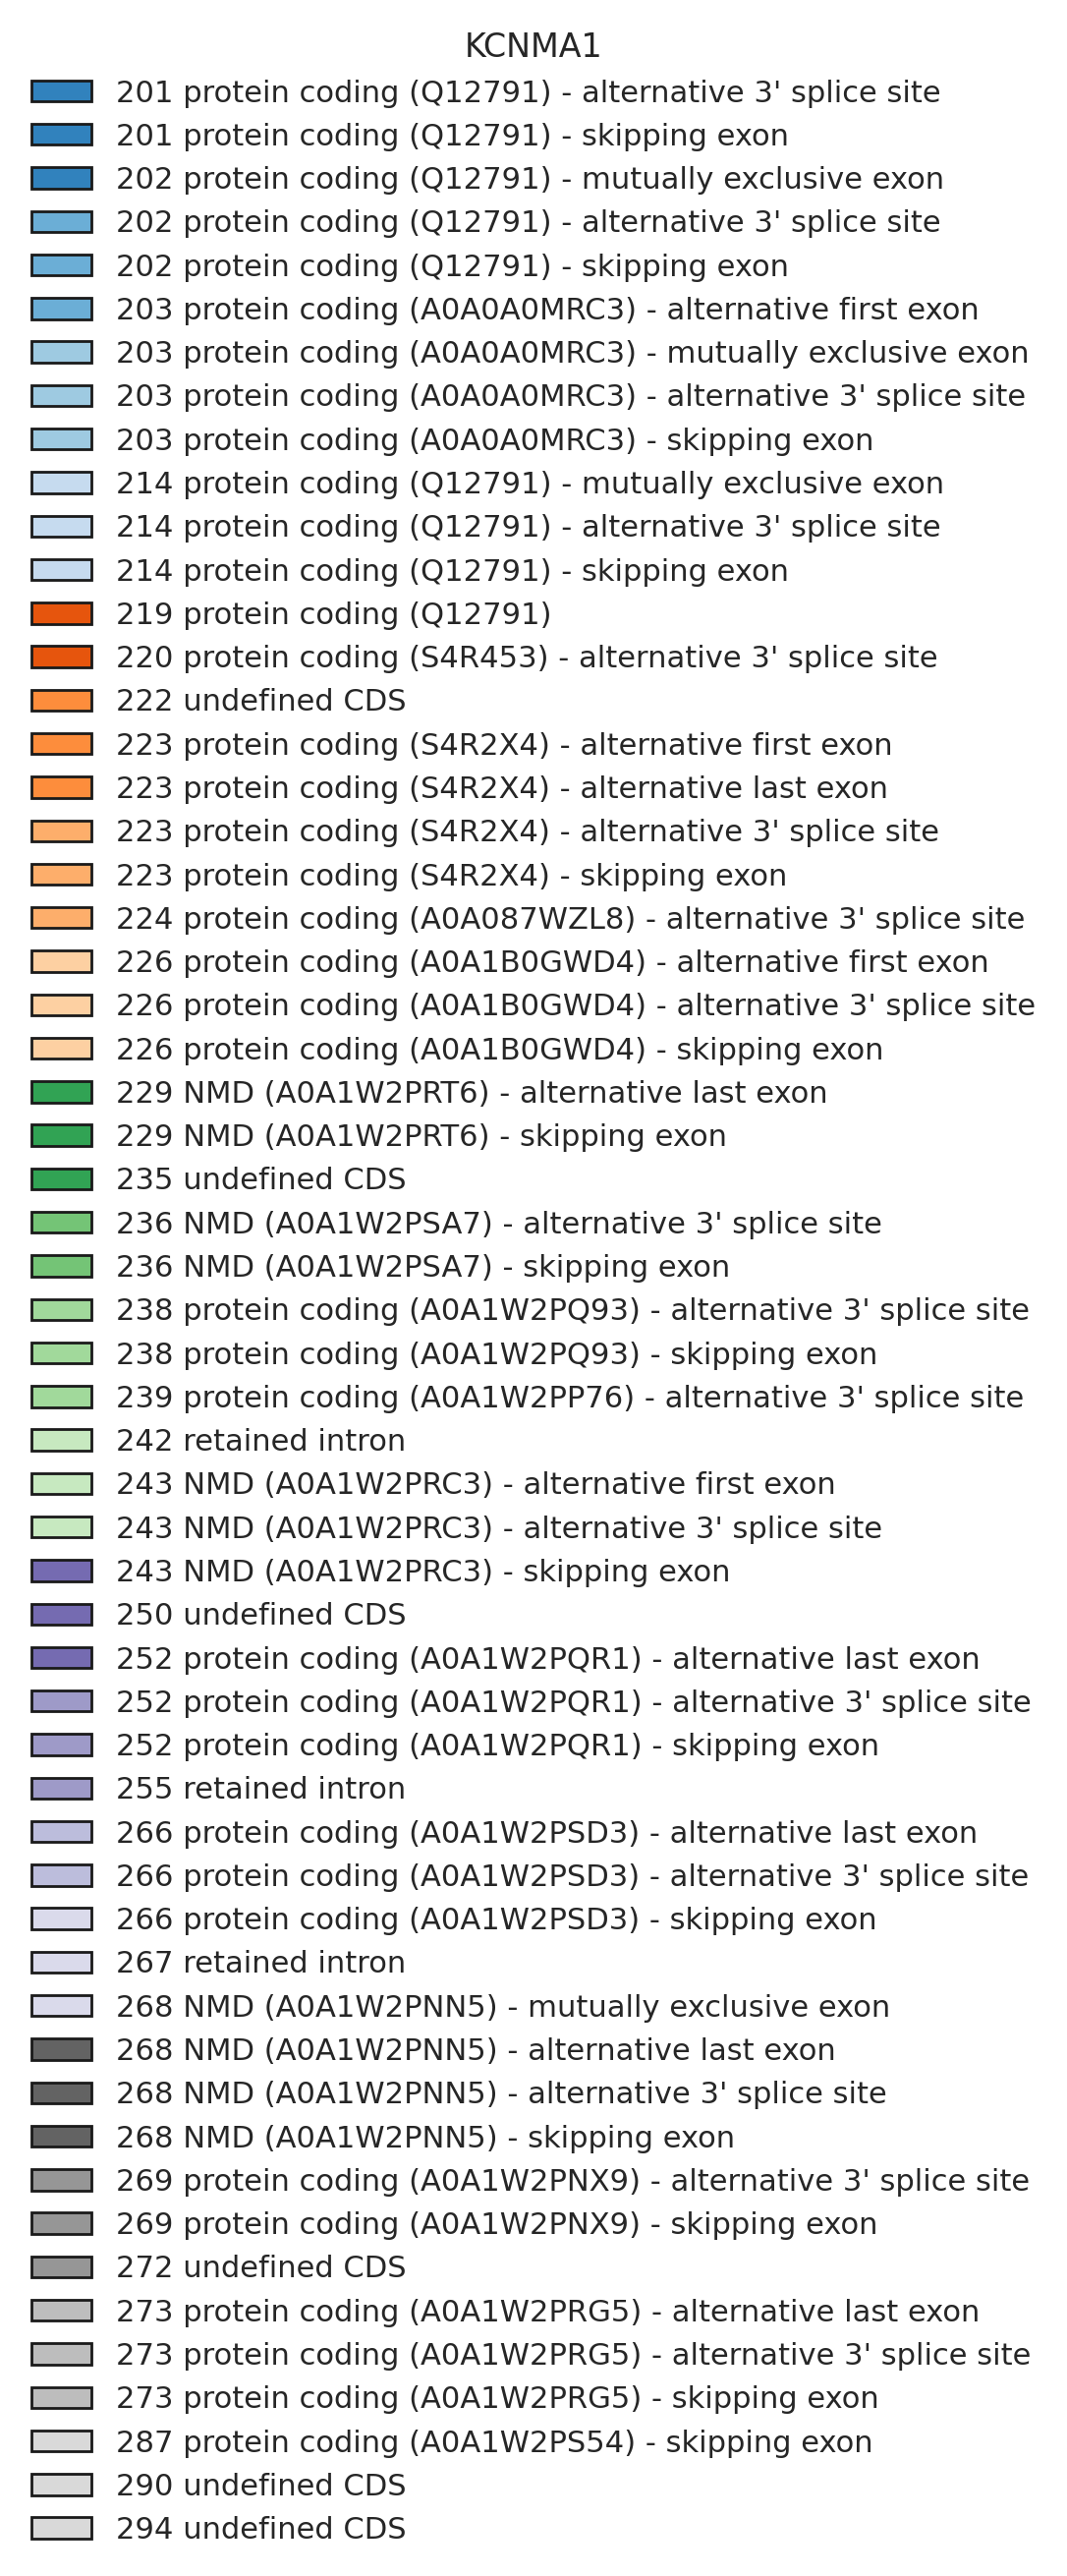

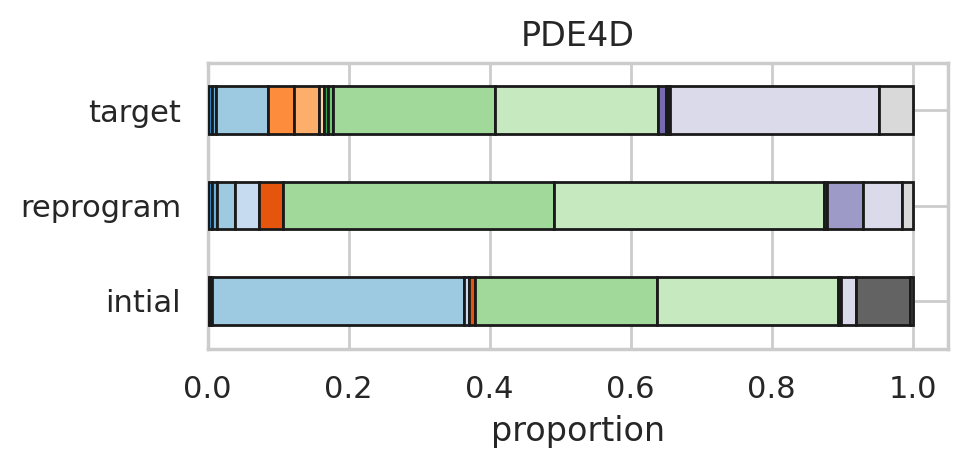

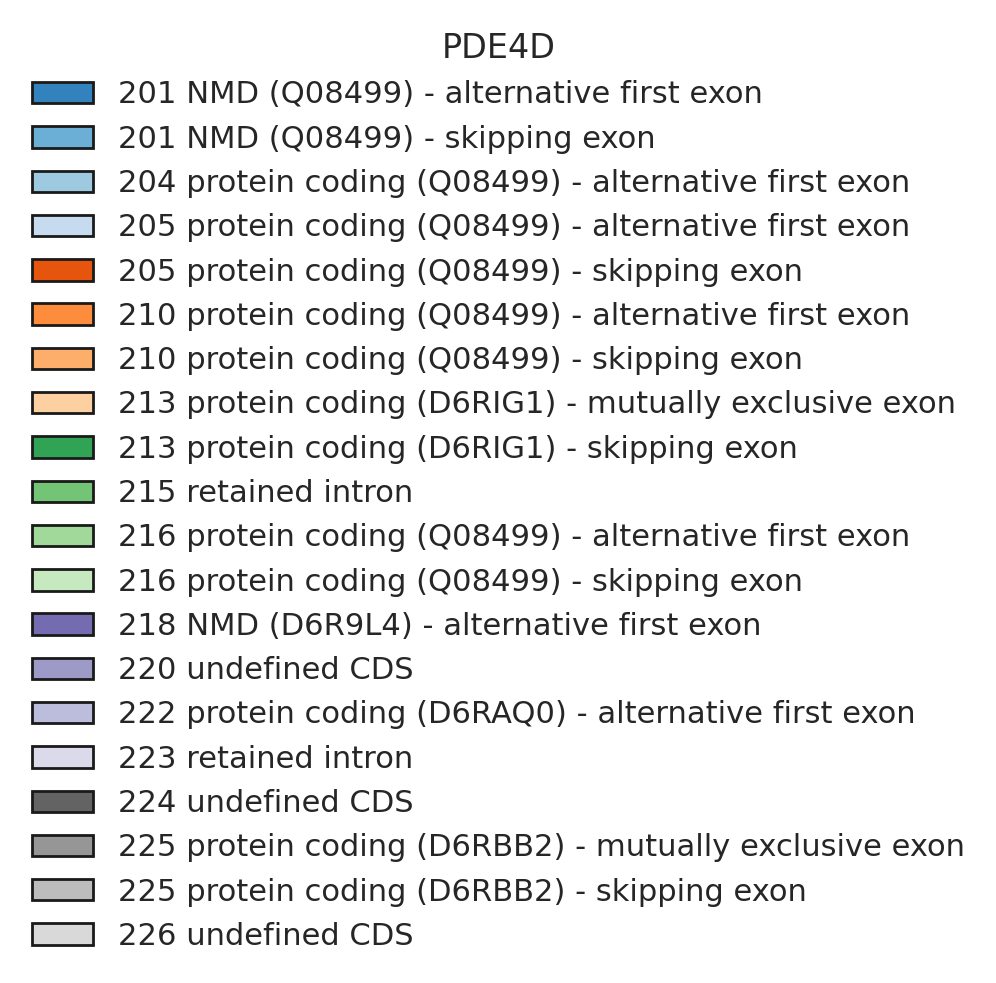

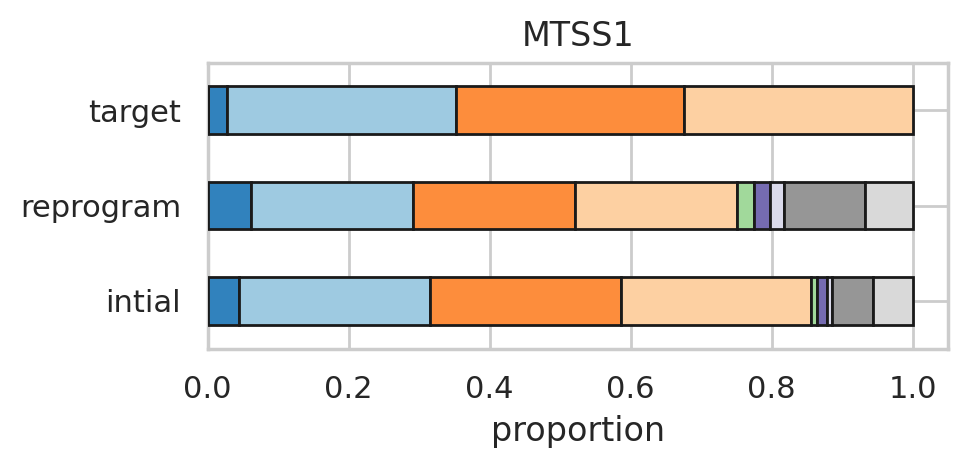

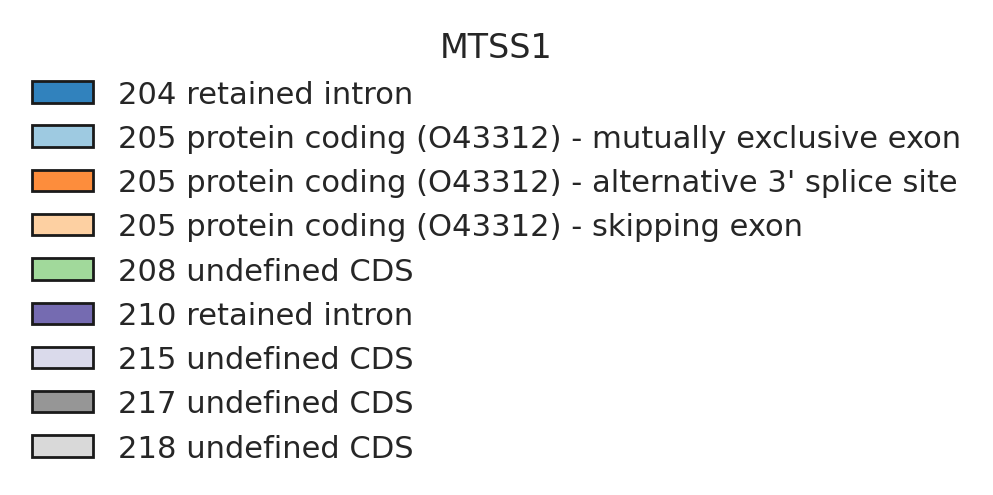

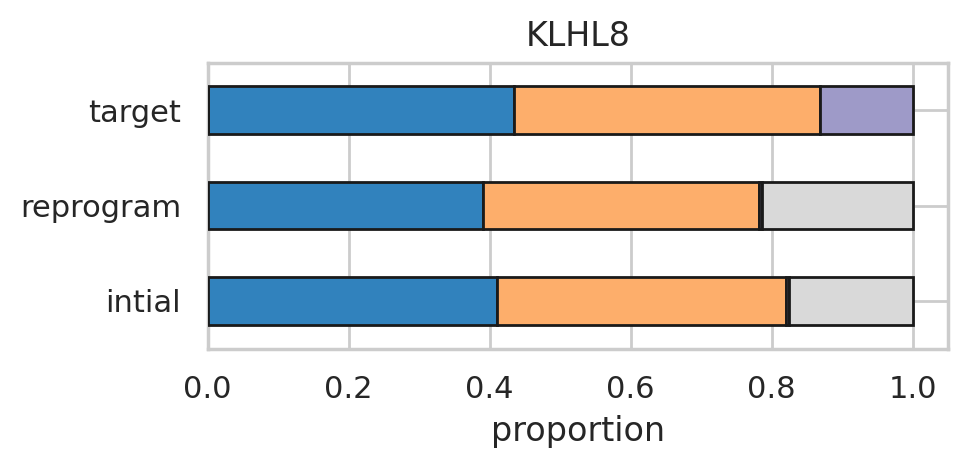

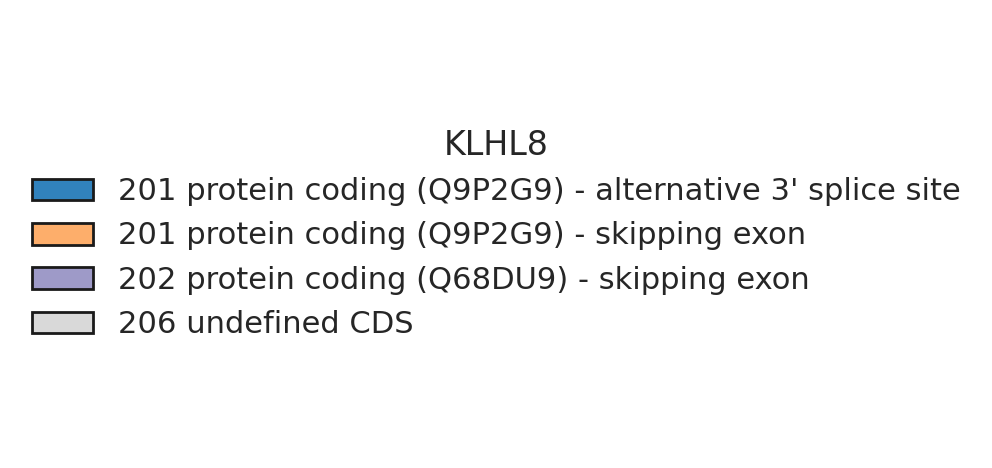

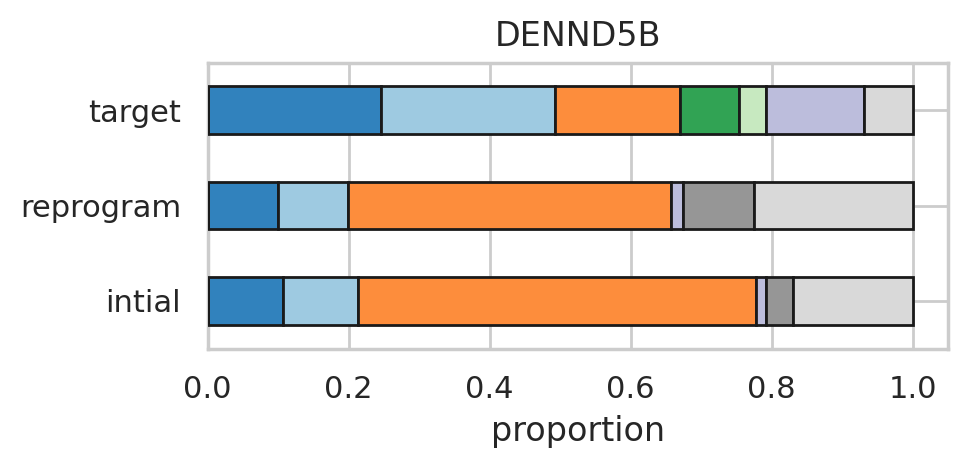

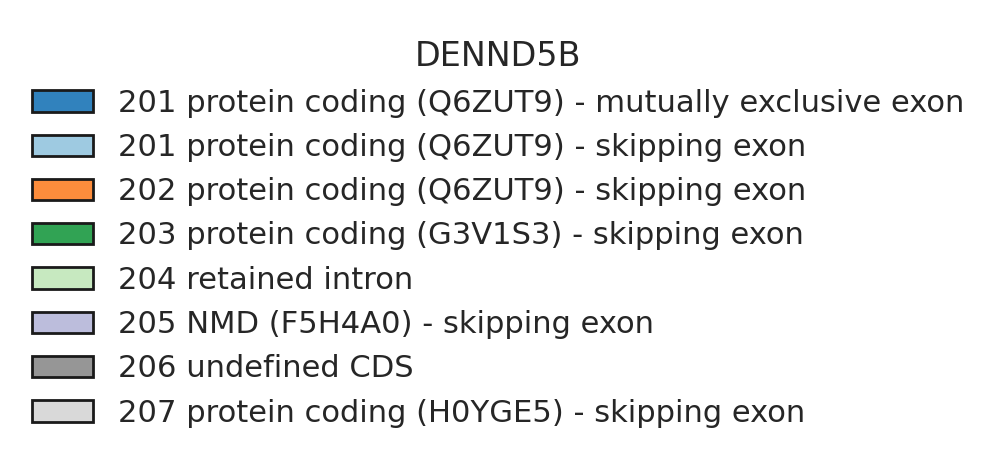

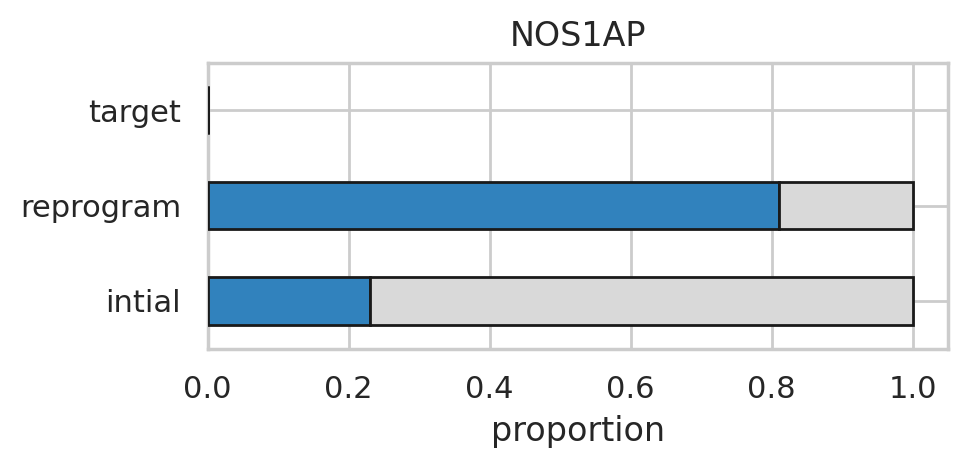

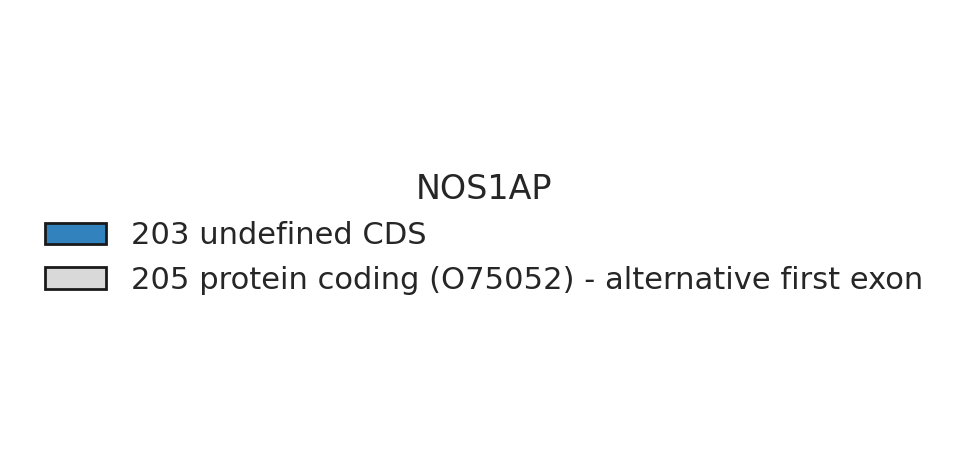

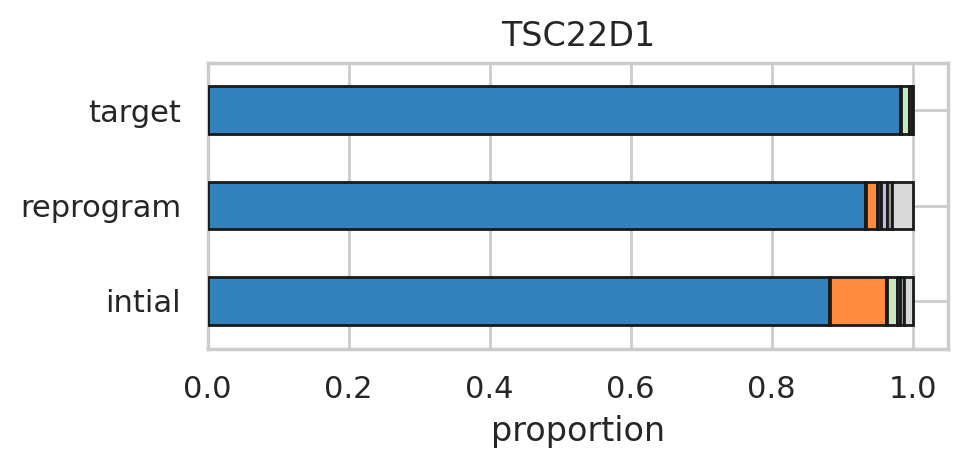

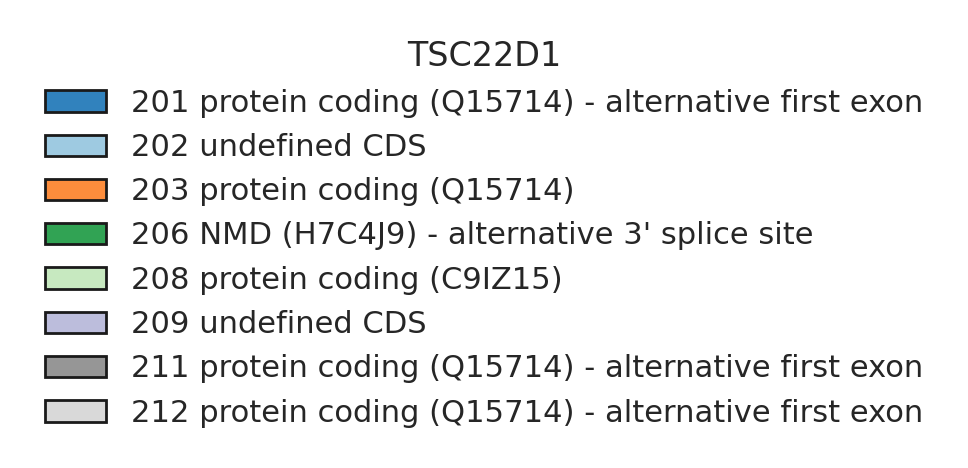

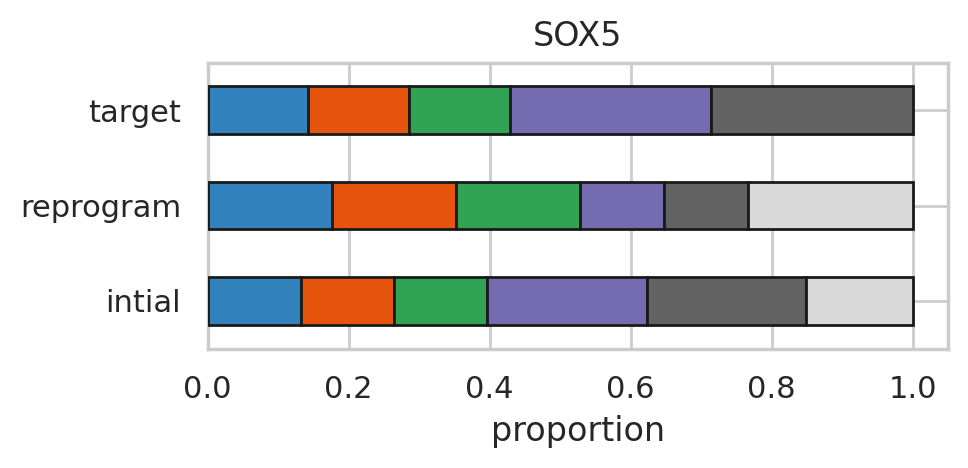

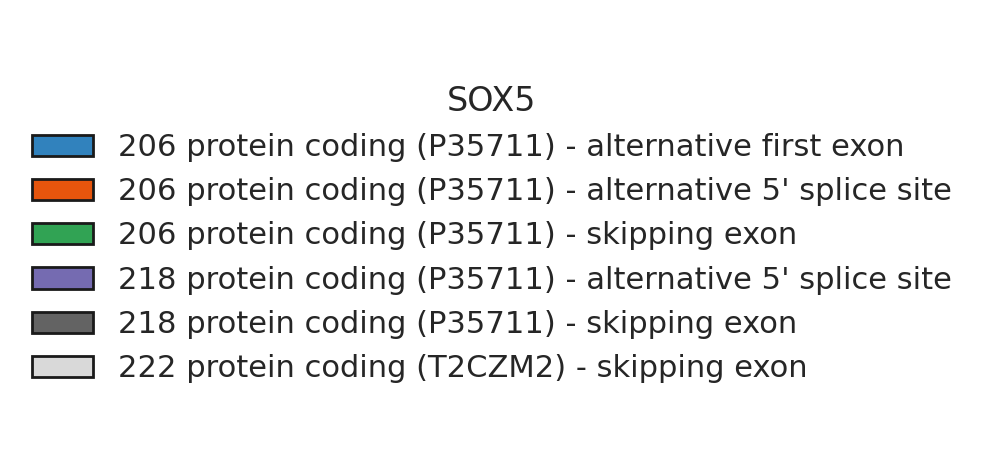

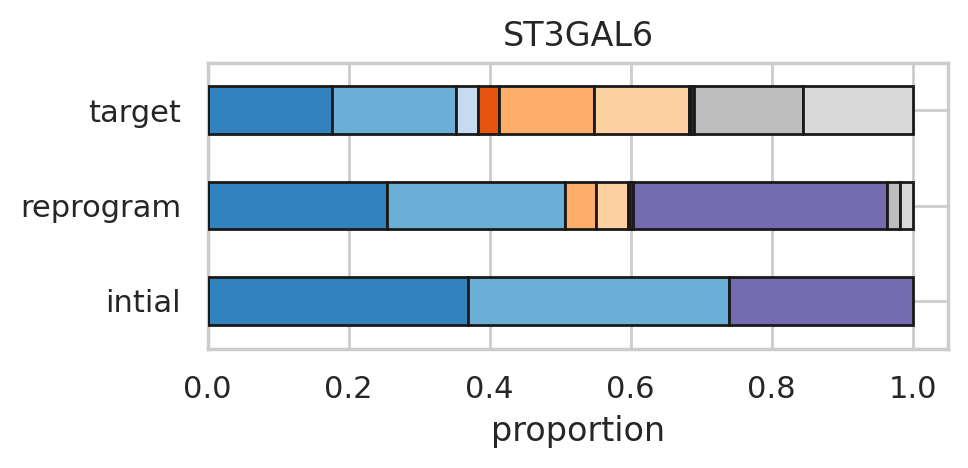

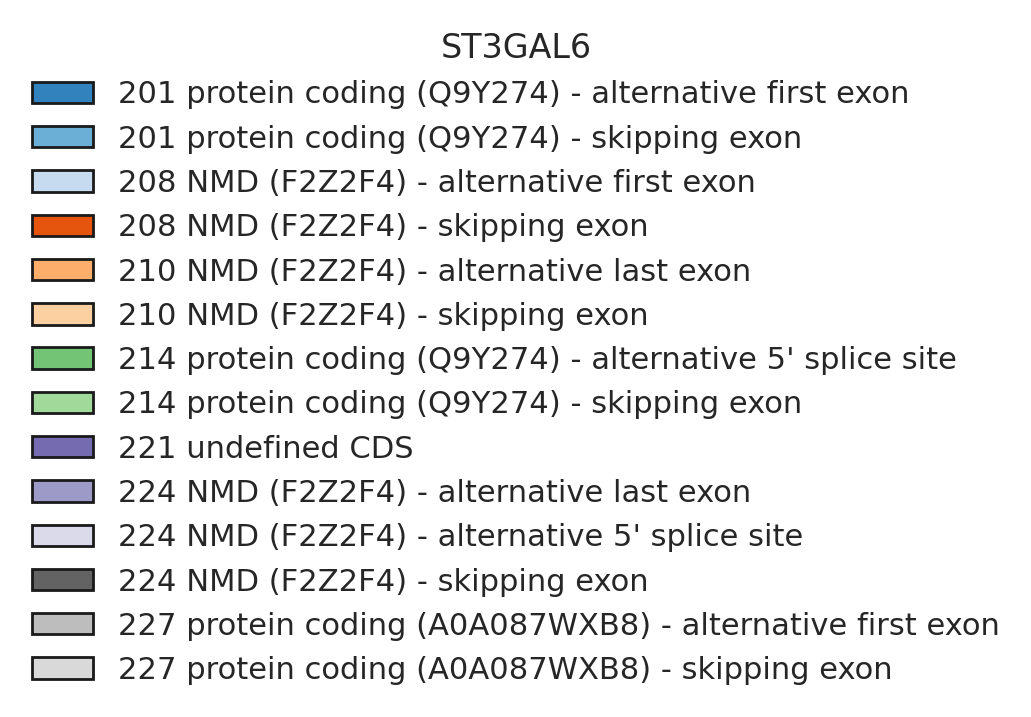

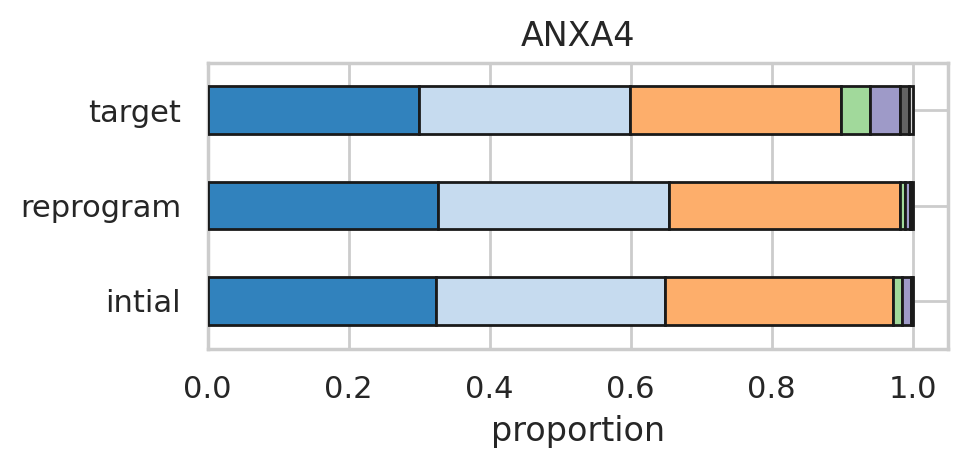

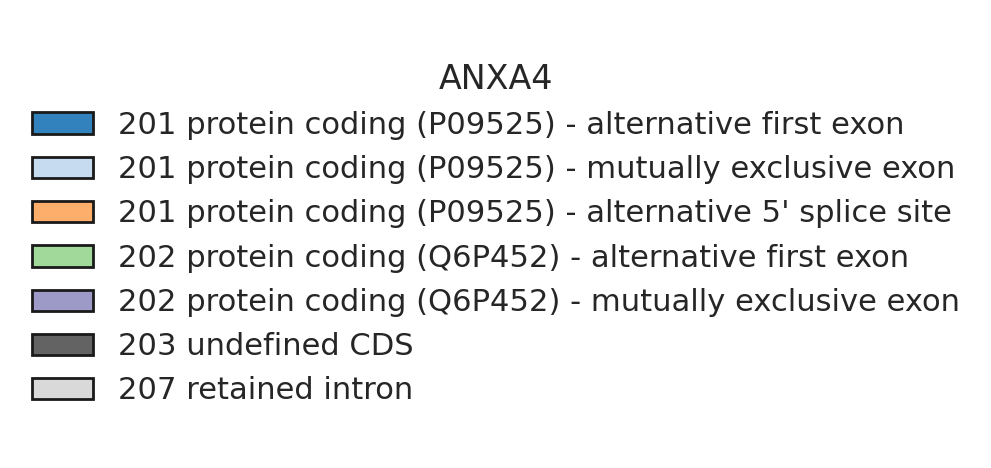

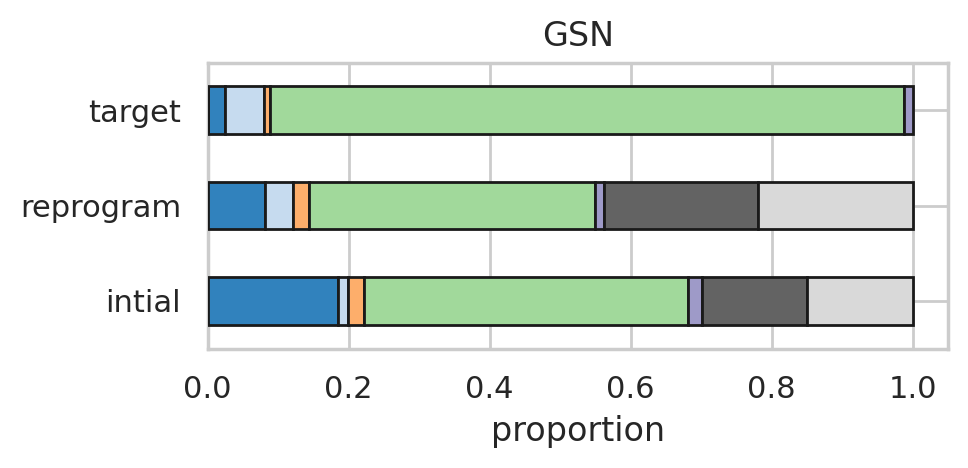

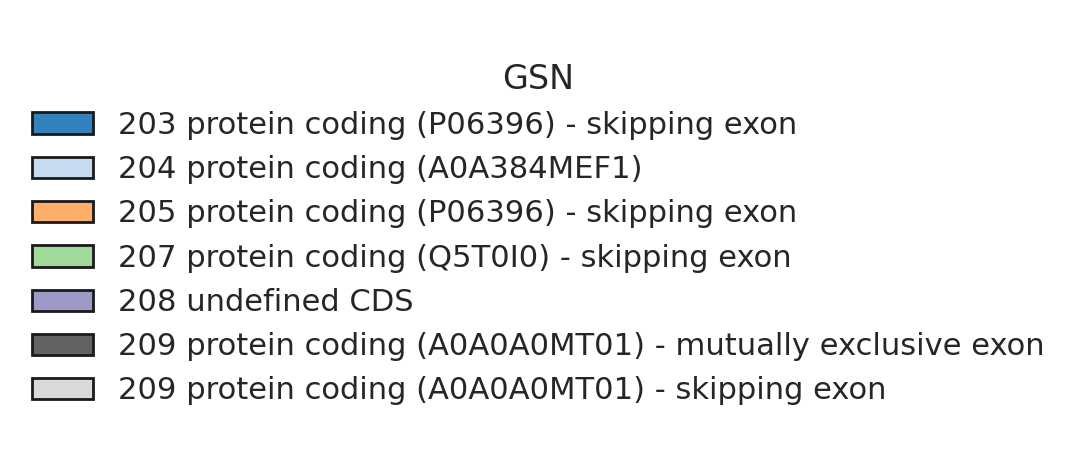

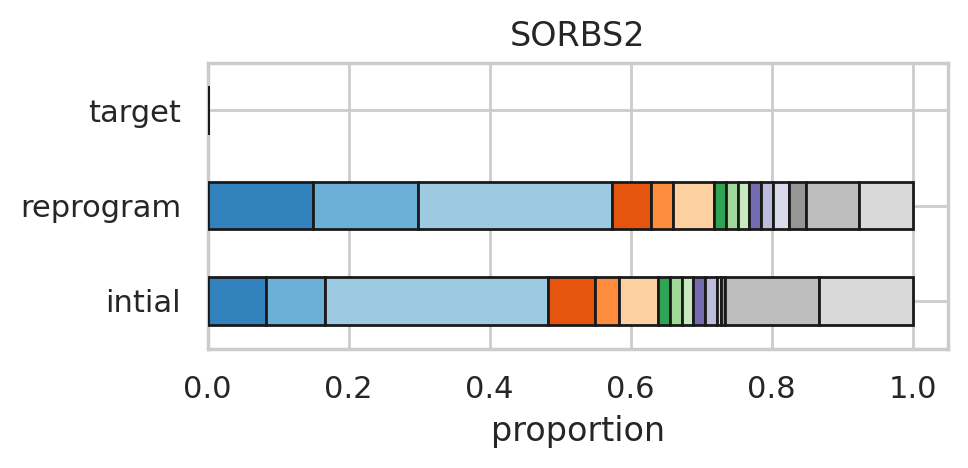

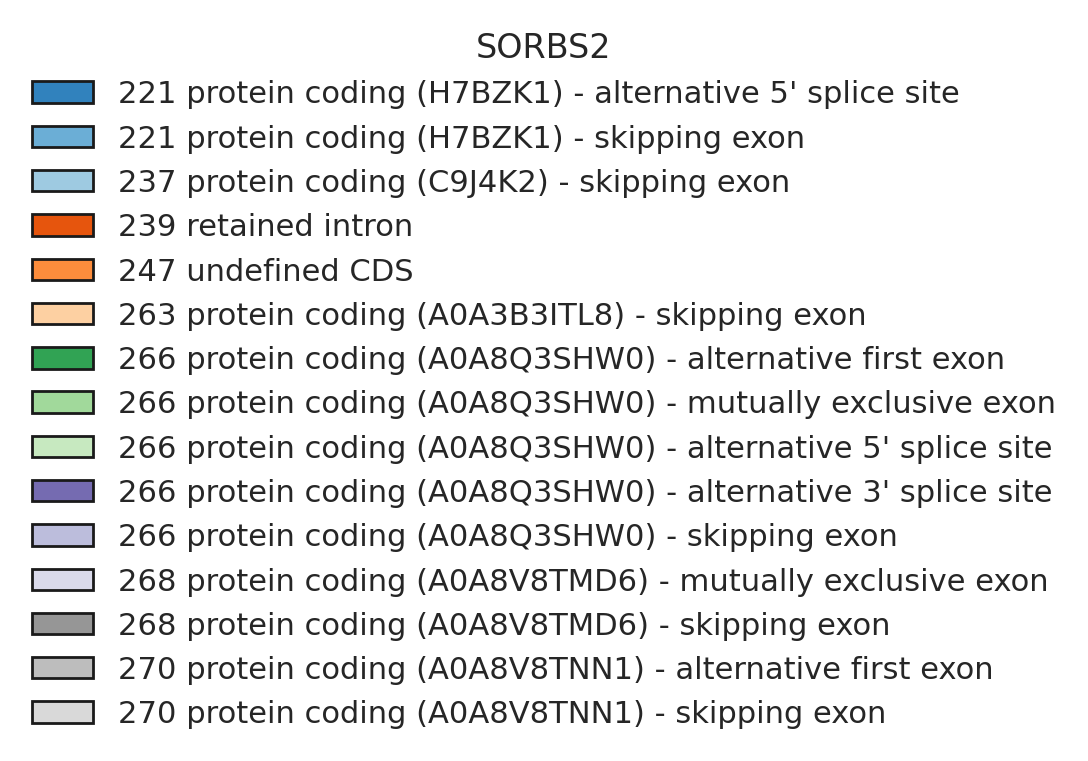

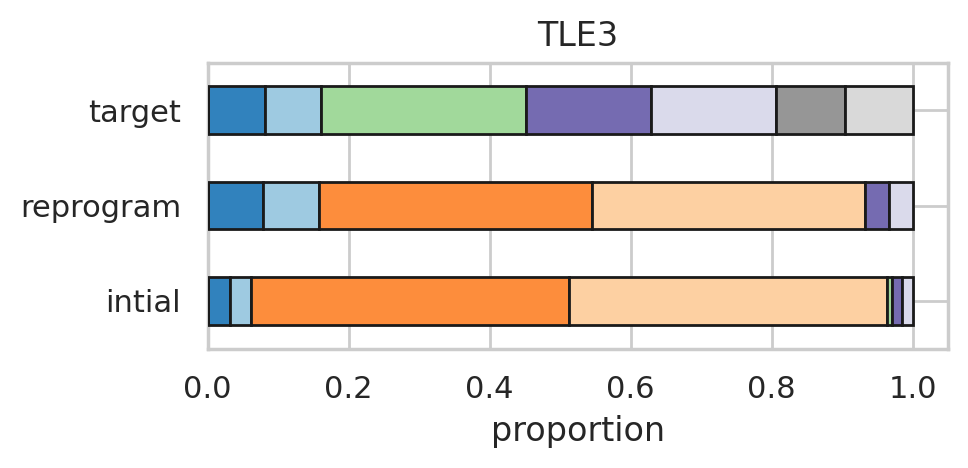

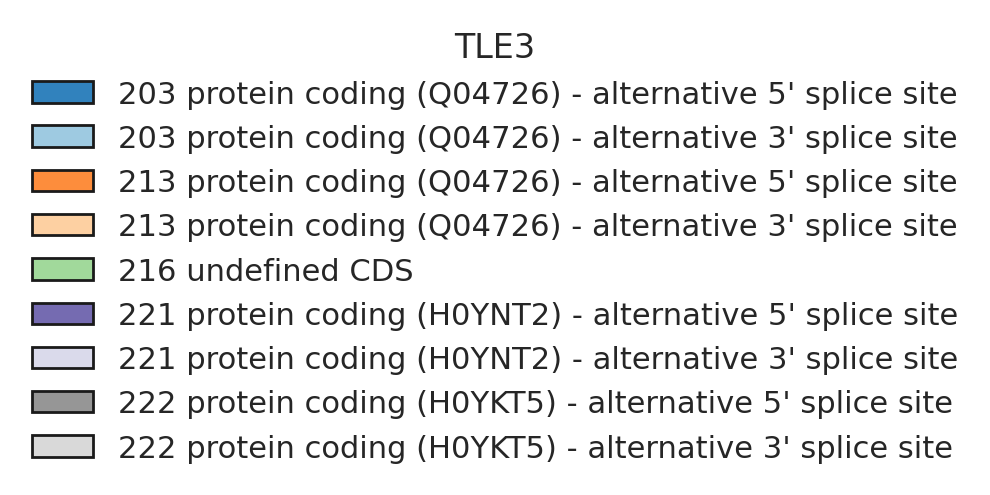

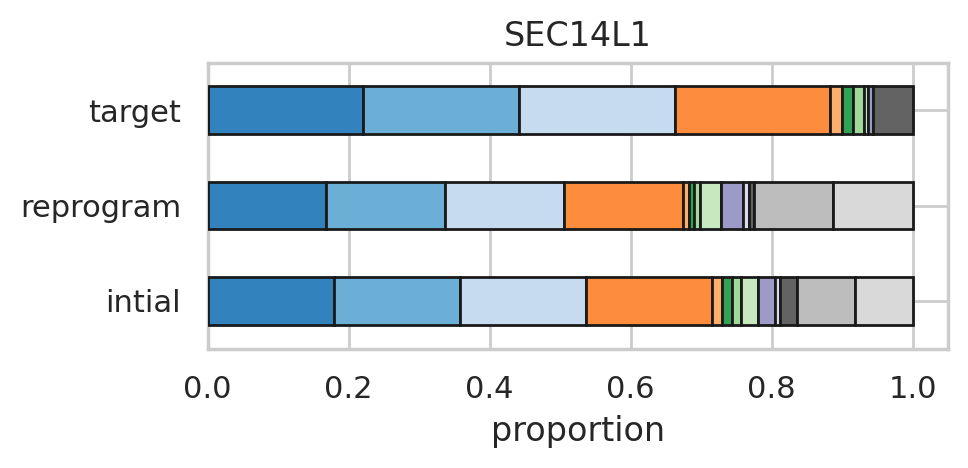

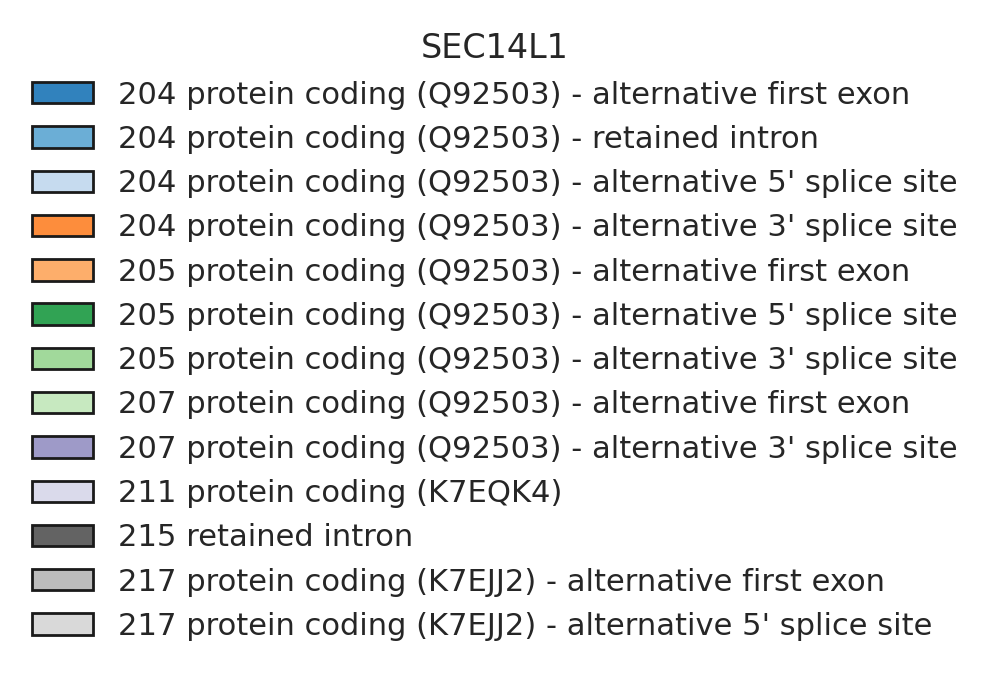

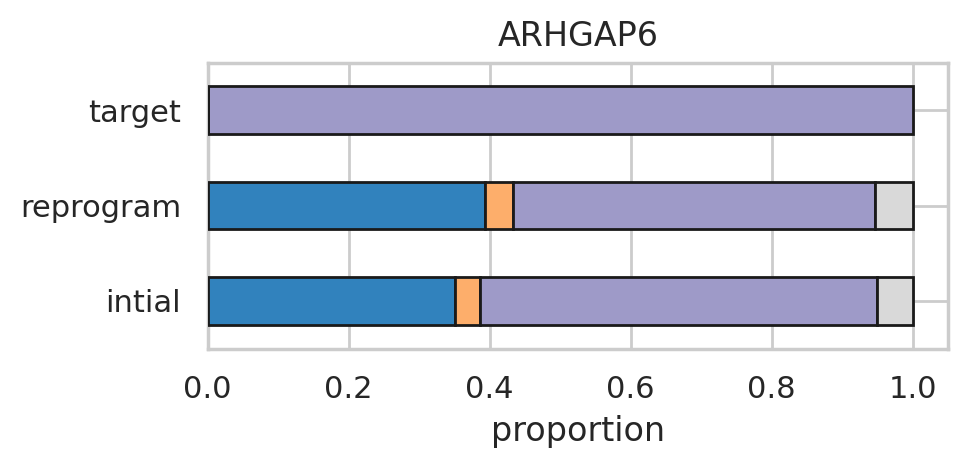

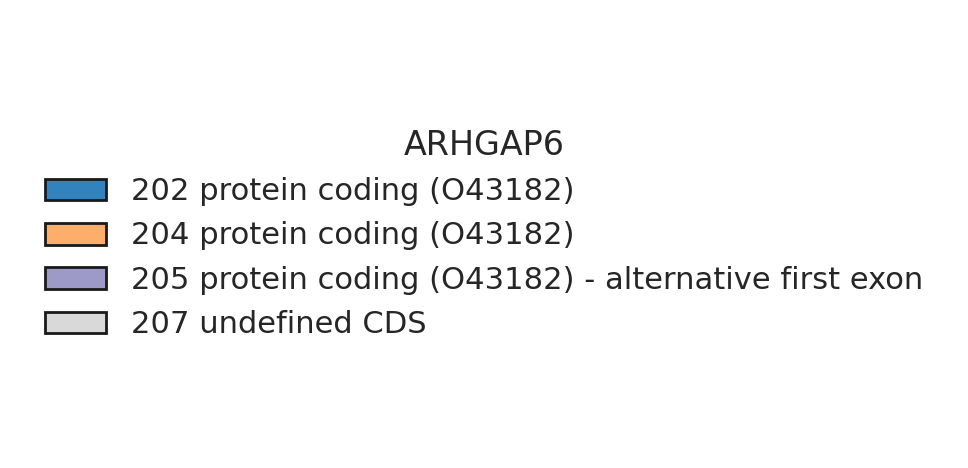

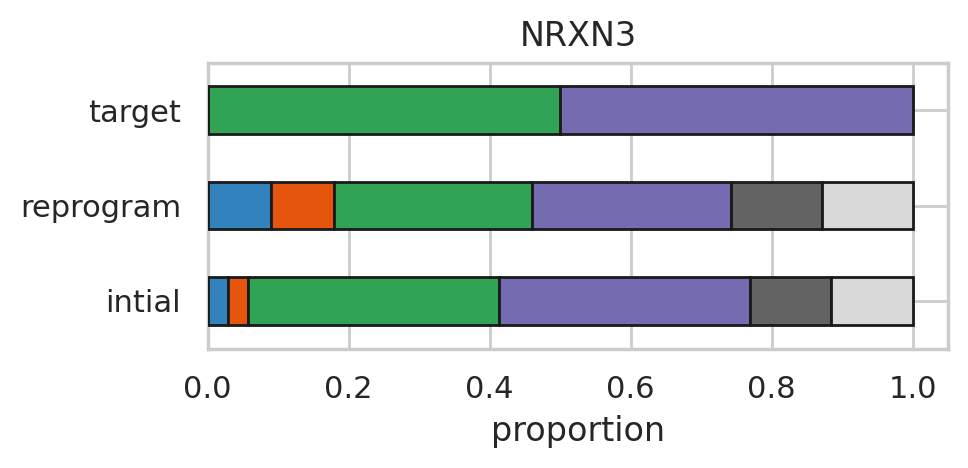

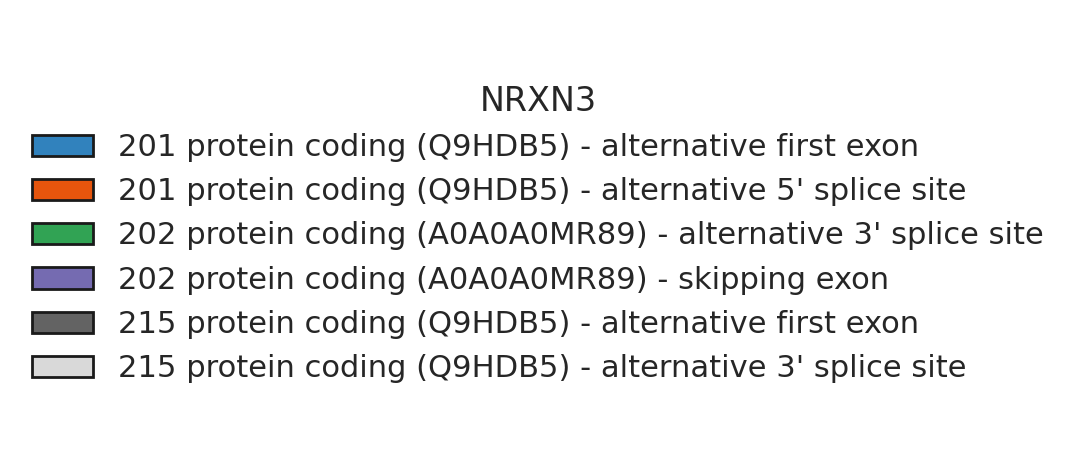

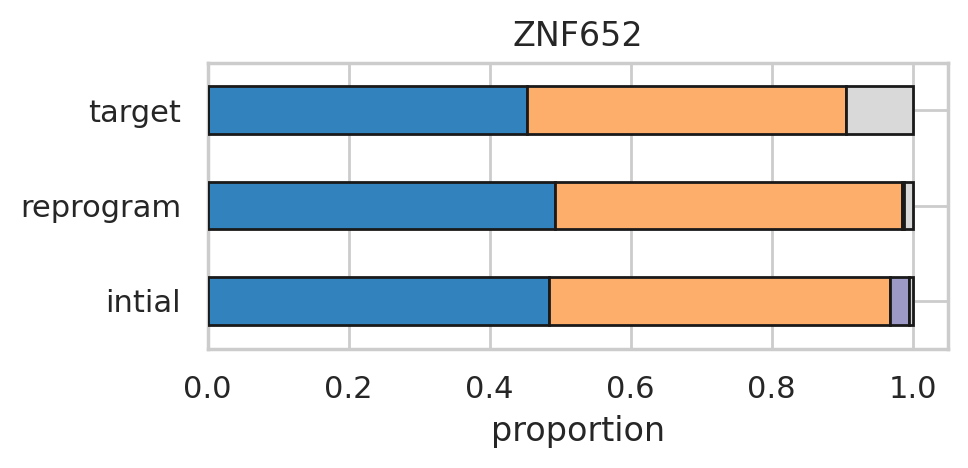

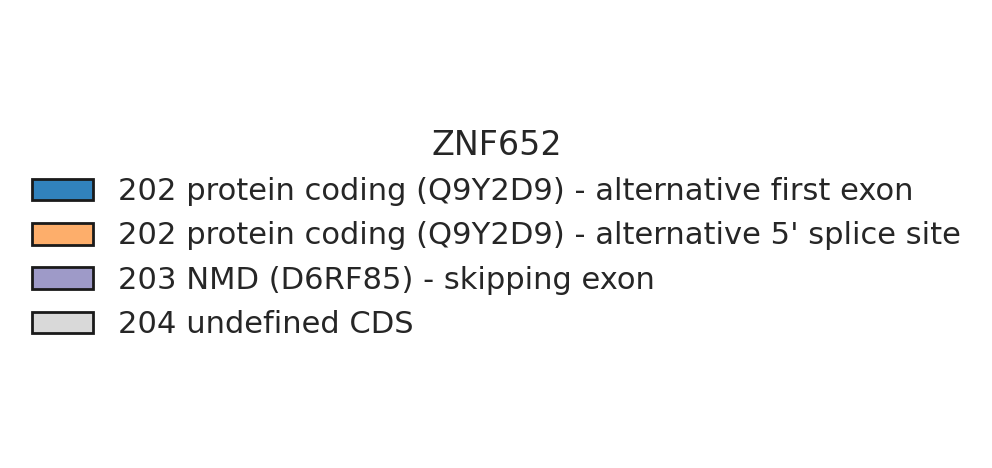

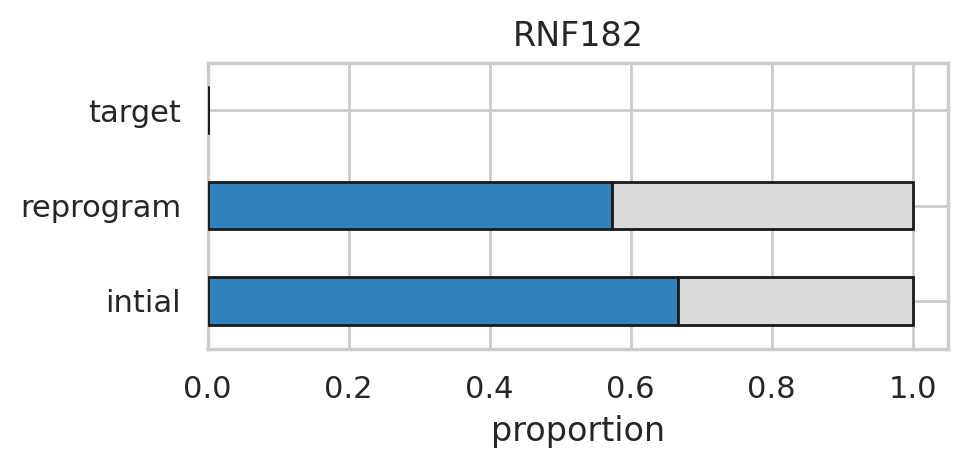

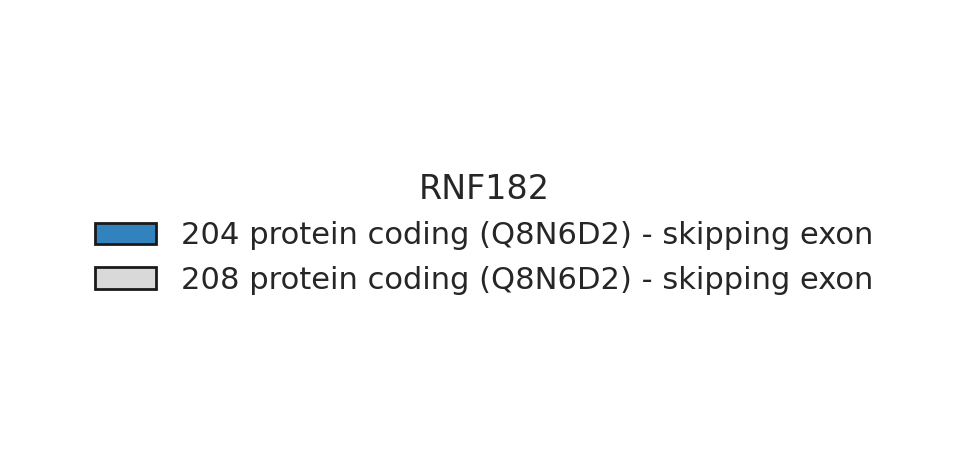

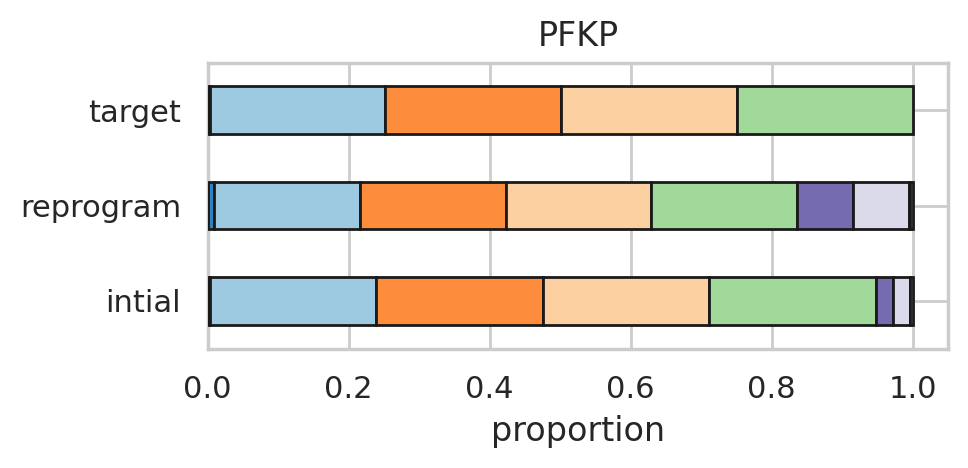

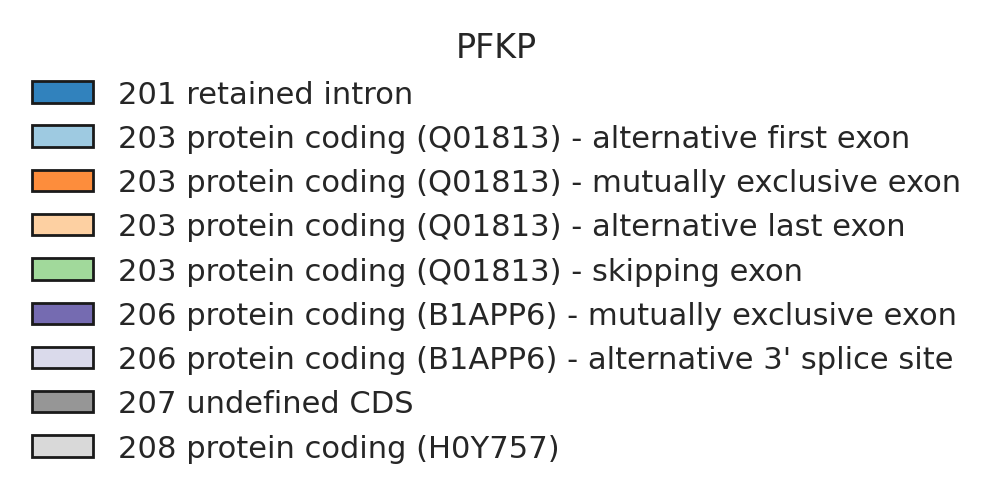

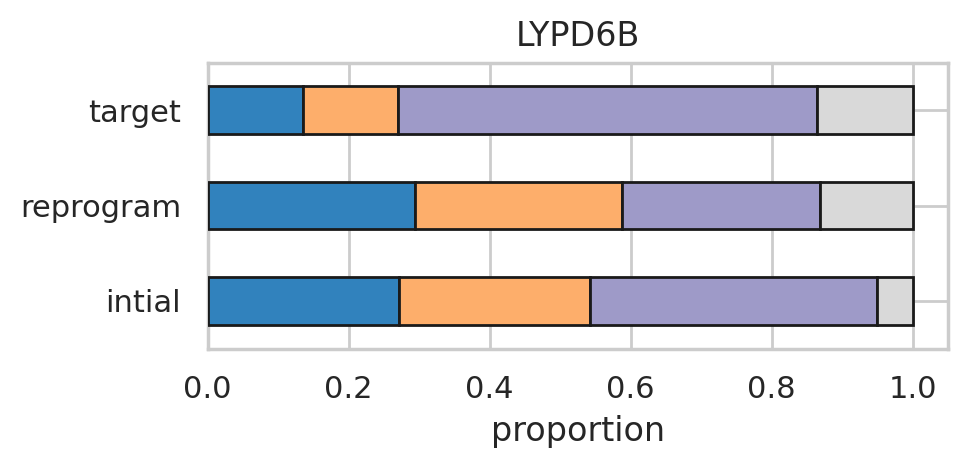

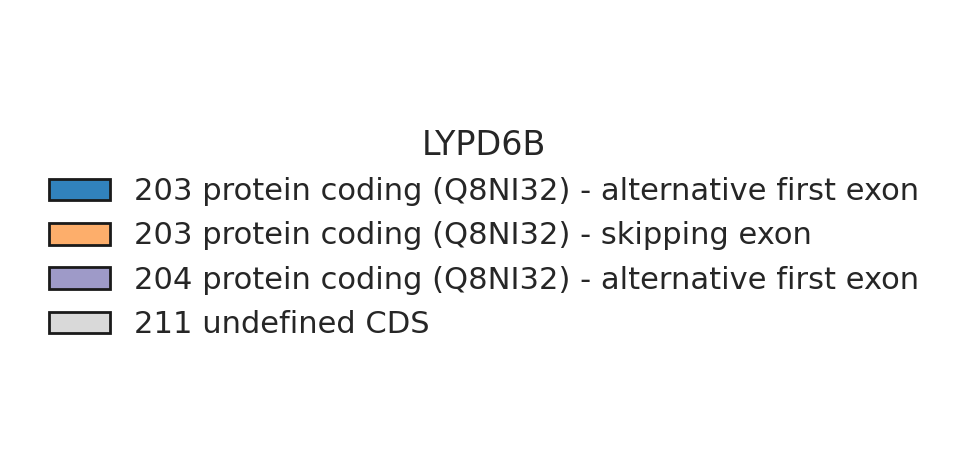

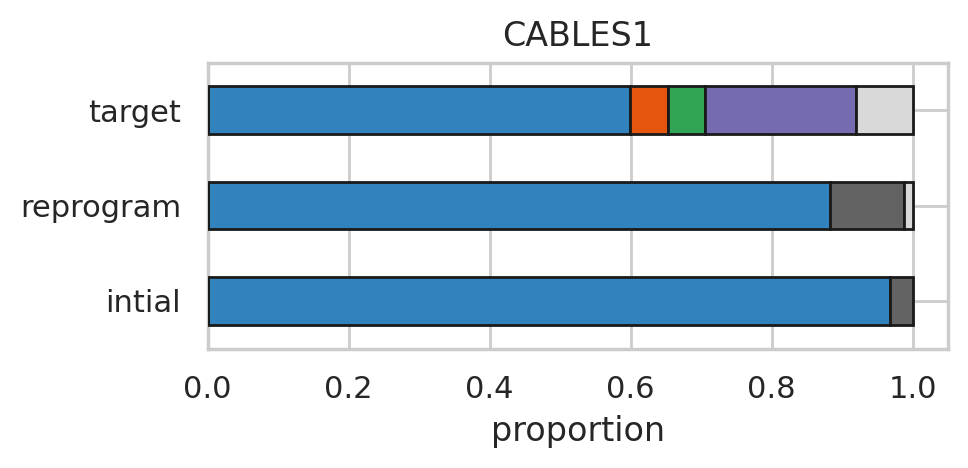

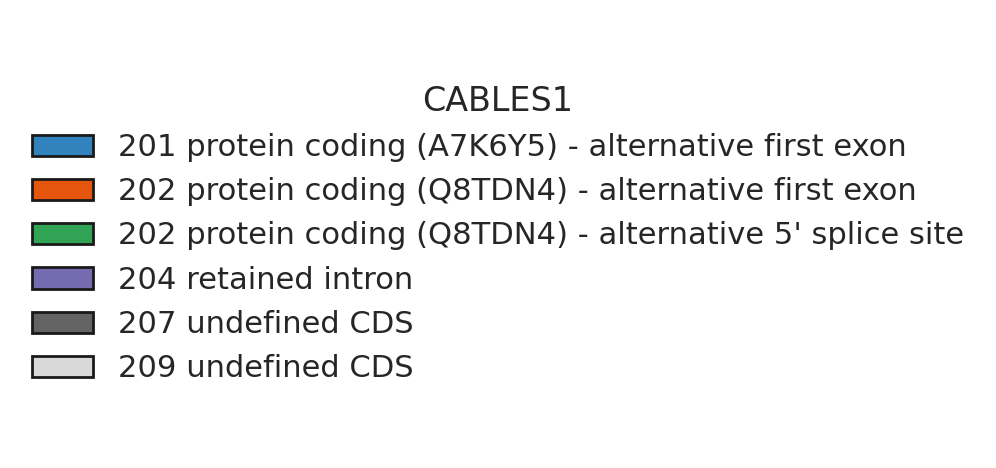

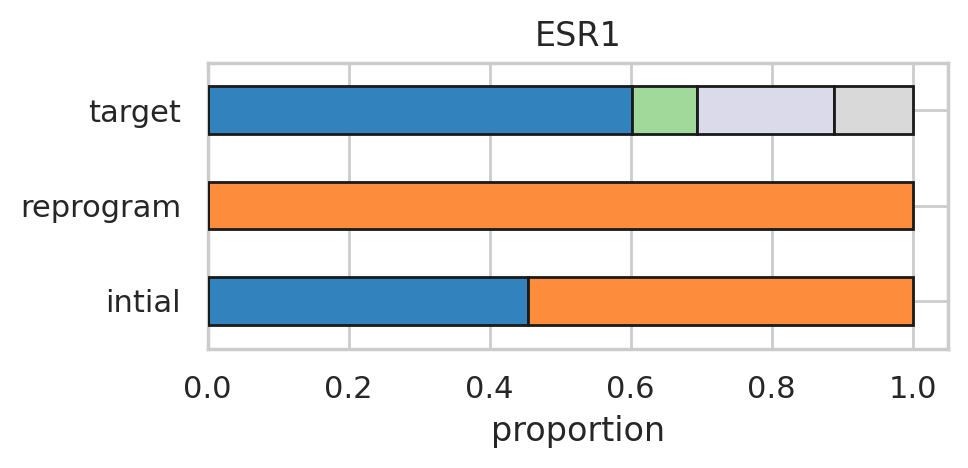

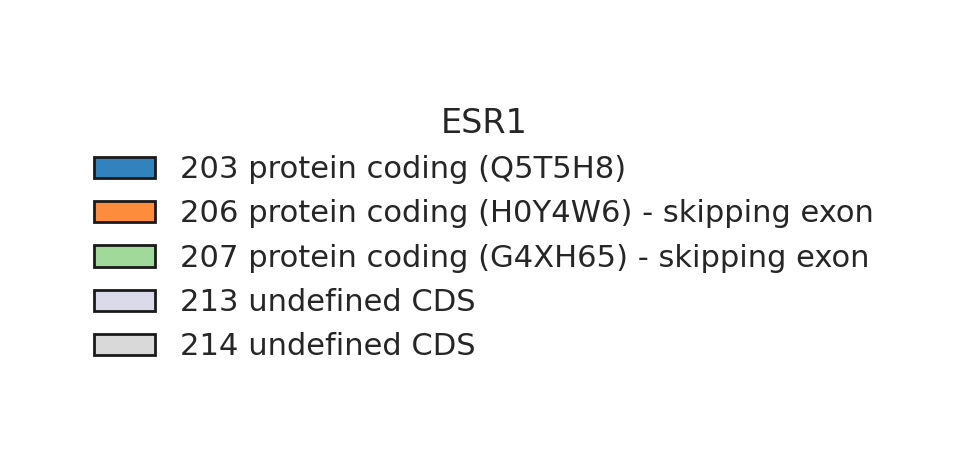

In [31]:
plot_df = pdf.copy()

columns = [
    'gene_name', 
    'transcript_name',
    'transcript_type',
    'uniprot',
    'event_label', 
    'n_isoforms',
    'n_protiens',    
    'intial_pct',
    'reprogram_pct',
    'target_pct',
    'total_gene',
]

plot_df = plot_df[columns]


type_labels = {
    'retained_intron':              ' retained intron',
    'protein_coding_CDS_not_defined':' undefined CDS',
    'lncRNA':                       ' lncRNA',
    'protein_coding':               ' protein coding',
    'nonsense_mediated_decay':      ' NMD',
    'non_stop_decay':               ' NSD',
    'protein_coding_LoF':           ' LOF',
}

plot_df['transcript_label'] = plot_df['transcript_name'].str.extract(r'(\d+)$')
plot_df['type_label'] = plot_df['transcript_type'].map(type_labels).fillna("")
plot_df['pt_label'] = np.where(plot_df['uniprot'].isna(), "", " (" + plot_df['uniprot'] + ")")
plot_df['event_label'] = np.where(plot_df['event_label'].isna(), "", " - " + plot_df['event_label'])

plot_df['annotation'] = plot_df['transcript_label'] + plot_df['type_label'] + plot_df['pt_label'] + plot_df['event_label']


plot_df.head()


for gene in gene_list:

    tmp = plot_df[plot_df['gene_name'] == gene]
    tmp = tmp.set_index('annotation')
    tmp = tmp[['intial_pct', 'reprogram_pct', 'target_pct']]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]

    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 5, 2.5

    # 1) Plot figure without legend
    fig1, ax1 = plt.subplots()
    tmp.T.plot(
        kind='barh',
        stacked=True,
        ec='k',
        zorder=10,
        width=0.5,
        cmap='tab20c',
        ax=ax1
    )
    ax1.grid(axis='y', zorder=0)
    ax1.set_xlabel("proportion")
    ax1.set_title(gene)
    # remove any auto‐legend
    ax1.legend().remove()
    fig1.tight_layout()
    fig1.show()
    
    # 2) Separate figure for the legend
    handles, labels = ax1.get_legend_handles_labels()
    
    fig2, ax2 = plt.subplots()
    ax2.axis('off')  # hide axes
    
    # draw legend in its own figure
    fig2.legend(
        handles,
        labels,
        title=gene,
        loc='center',
        ncol=1,              # or len(labels) for a single row
        frameon=False
    )
    fig2.tight_layout()
    fig2.show()

    # print(plot_df.head())
    # break

In [32]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
pdf[pdf['gene_name'] == 'SELENOS'][columns]

In [ ]:
break

# marker gene dominance

In [ ]:
# fpath = "../../resources/clean_marker_genes.csv"
# mdf = pd.read_csv(fpath)
# print(f"{mdf.shape=}")
# mdf.head()

# SCENIC genes

In [ ]:
gene_list = ['PPARG', 'SLC12A6', 'ZFHX3', 'NFATC1', 'FOXN3', 'ZMIZ2', 'PTPN21',
       'ABLIM1', 'BCL2L1', 'KCNMA1', 'STXBP6', 'USP3-AS1', 'ICA1L',
       'PDE4D', 'MTSS1', 'CCT6P3', 'KLHL8', 'RABGAP1L', 'TTC7A', 'DNMBP',
       'STXBP5', 'NCOA6', 'SESN1', 'MAPT', 'DENND5B', 'TSC22D1', 'NOS1AP',
       'PRKAG2', 'AGAP3', 'VGLL4', 'SOX5', 'GABRB3', 'CYTH1', 'BCAR3',
       'DCHS2', 'CBFA2T2', 'ST3GAL6', 'SVIL', 'ACSL1', 'ANXA4', 'STRA6',
       'FLVCR2', 'SORBS2', 'DCUN1D1', 'SLC24A4', 'SHANK2', 'GSN', 'HIPK3',
       'TRAK1', 'PRKX', 'TPD52', 'INPP4A', 'TLE3', 'CRLS1', 'RERE',
       'PDPN', 'SGK1', 'MTM1', 'SEC14L1', 'SYNM', 'SLC35F3', 'SATB2',
       'NCOA2', 'NRXN3', 'DLG2', 'FGF14', 'KAT2B', 'FLCN', 'SSH2',
       'ASAP1', 'ARHGAP6', 'IGFBP6', 'PACSIN2', 'CCM2', 'CREB5', 'LYPD6B',
       'ZNF652', 'TBC1D14', 'CHSY1', 'RNF182', 'CLDN14', 'BFSP1',
       'ADAMTS7', 'RCAN3', 'PCOLCE2', 'FKBP5', 'PFKP', 'FHIT', 'KCTD1',
       'IQSEC1', 'CABLES1', 'MINK1', 'ABCG1', 'ESR1', 'PMEPA1', 'LRRC20',
       'RABL2A', 'TBC1D4', 'EPB41L5', 'CDK6', 'SSUH2', 'ARHGEF3', 'RNF38',
       'TBC1D8', 'OSBP2', 'FNBP1L', 'PPP6R2', 'CDH23', 'PLEKHG5', 'PSD3',
       'CHODL', 'NIPA1', 'MCCC1', 'ANK1', 'SMAD3', 'AFF1', 'TMCC1',
       'TEX2', 'AHCYL2', 'CLU', 'CDC14B', 'RAI1', 'ZSCAN5A', 'CDH12',
       'LPIN1', 'CBLB', 'CAPG', 'LIMD1', 'EYA4', 'GFOD1', 'BRAF', 'PRR5L',
       'CDYL2', 'CACNB4', 'AKAP13', 'PRSS48', 'ECE1', 'HPCAL1', 'RAMP1',
       'SPSB1', 'FTCDNL1', 'TTYH1', 'TMEM164', 'EHD1', 'GAS7', 'ABCC3',
       'AK4', 'SH3D19', 'ABL1', 'STAT5A', 'TLE2', 'MLLT10', 'TOX2', 'MAK',
       'WNT16', 'RCL1', 'CLIP1', 'DCUN1D3', 'KCNAB1', 'NIPAL3', 'DGKD',
       'EGFR', 'TRIM2', 'NLRC4', 'ZNF608', 'LINC01010', 'TUBA4A',
       'SETBP1', 'GCNT1', 'LINC00511', 'PROSER2', 'KCNMB3', 'RHBDL2',
       'GIPC2', 'GREB1L', 'ABAT', 'SGMS2', 'SEC24A', 'ZNF566', 'ZNRF1',
       'SHTN1', 'MTMR11', 'PLEKHM3', 'GRB10', 'TANC1', 'HOXC10', 'DDI2',
       'AREG', 'UBE2H', 'ANGPT2', 'SCHIP1', 'MICAL3', 'NFAT5', 'TRPV1',
       'MARK2', 'DCAF5', 'PC', 'SNCA', 'FRMD3', 'RAPGEF1', 'SLC37A4',
       'SH3YL1', 'RAD52', 'SPIN2B', 'BAIAP2L1', 'SLMAP', 'DIXDC1',
       'ZNF564', 'KRT8', 'SRPK2', 'FBXW4', 'WBP1L', 'C2CD2', 'EGLN1',
       'B3GNT2', 'ATP6V1A']

In [ ]:
plot_df = pdf.copy()

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
mask = plot_df[top_cols].nunique(axis=1, dropna=False) < 3
plot_df = plot_df[~mask]
print(f"{plot_df.shape=}")

plot_df = plot_df[plot_df['gene_name'].isin(gene_list)]
print(f"{plot_df.shape=}")

plot_df['protien_id'] = plot_df['transcript_name'].map(transcript_2_uniprot)
plot_df['n_protien'] = plot_df.groupby('gene_name')['protien_id'].transform('nunique')
plot_df = plot_df[plot_df['n_protien'] > 1]
print(f"{plot_df.shape=}")
print(f"{plot_df['gene_name'].nunique()=}")


for gene in plot_df['gene_name'].unique():
    print(f"{'=' * 10} {gene} {'=' * 10}")
    tmp = plot_df[plot_df['gene_name'] == gene]
    print(f"{tmp.shape=}")
    transcripts = tmp['transcript_name'].to_list()

    plot_gene_heatmap(gene, plot_df, transcript_2_uniprot)
    plot_transcript_models(exons, transcripts)

In [ ]:
break

In [ ]:
plot_df = pdf.copy()

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['intial_pct_top', 'reprogram_pct_top', 'target_pct_top']
mask = plot_df[top_cols].nunique(axis=1, dropna=False) == 1
plot_df = plot_df[~mask]


# """ Random sampling """
# sample_size = 10
# gene_list = pd.Series(plot_df['gene_name'].unique()).sample(sample_size).values

for gene in gene_list:
    print(f"{'=' * 10} {gene} {'=' * 10}")
    tmp = plot_df[plot_df['gene_name'] == gene]
    print(f"{tmp.shape=}")
    transcripts = tmp['transcript_name'].to_list()

    plot_gene_heatmap(gene, plot_df, transcript_2_uniprot)
    plot_transcript_models(exons, transcripts)

    # break
    

In [ ]:
def plot_isoform_stack(pdf, gene_name, figsize=(2, 3.5), cmap='tab20b'):
    """
    Plot a stacked bar chart of isoform percentages by condition for a given gene.

    Parameters:
    - pdf: DataFrame containing columns: gene_name, transcript_name, *_sum, *_pct
    - gene_name: str, gene to plot
    - figsize: tuple, figure size
    - cmap: matplotlib colormap name
    """
    # Subset data
    df = pdf[pdf['gene_name'] == gene_name].copy()

    # Extract isoform fractions
    pct_df = df[['transcript_name', 'intial_pct', 'reprogram_pct', 'target_pct']].set_index('transcript_name')
    pct_df.columns = [col.replace("_pct", "") for col in pct_df.columns]
    pct_df = pct_df.T

    # Plot
    ax = pct_df.plot(
        kind='bar',
        stacked=True,
        figsize=figsize,
        width=0.7,
        edgecolor='black',
        zorder=10,
        cmap=cmap,
    )

    # Get sums from first row
    sums = df.iloc[0][['intial_sum', 'reprogram_sum', 'target_sum']]
    sums.index = [col.replace("_sum", "") for col in sums.index]

    # Annotate sums
    for i, (label, total) in enumerate(sums.items()):
        ax.text(i, 1.02, f"{int(total):,}", ha='center', va='bottom', fontsize=8)

    # Style
    plt.ylim(0, 1.1)
    plt.grid(axis='y')
    plt.ylabel("% of total")
    plt.xlabel("")
    plt.title(f"{gene_name}")
    plt.legend(
        title="isoform",
        bbox_to_anchor=(2.0, 0.5),
        loc='center right',
    )
    plt.tight_layout()
    plt.show()

plot_isoform_stack(pdf, "AIF1")

# SCENIC GENES

# Literature genes

In [ ]:
gene_list = [
    "IKZF1", "NFIB", "MDM4", "RUNX1", "HMGA2", "NUMB", "NOTCH", "LAS1L", "ATP5F1C", "HDAC7",
    "CPSF3", "HNRNP UL1", "TIA1", "PTBP1", "SRSF3", "RBFOX2", "SRSF2", "SRSF1", "RUNX1A", "CLK3",
    "SRSF2", "RUNX1", "GATA2", "ETV2", "TAL1",
    "HBA1", "HBB", "ALB", "TFRC", "GATA1", "CD34", "CD3D", "CD19", "VWF", "MPO", "PF4", "PRTN3",
    "KLF1", "MYB", "GFI1B", "SPI1", "PBX1", "MEIS1",
    "U1/U2/U4/U5/U6 SNRNPS", "SRSF1-7", "SF3B1", "PRPF8", "RBM PROTEINS", "HNRNPS"
]

for gene in gene_list:
    if gene in pdf['gene_name'].unique():
        plot_isoform_stack(pdf, gene)


In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

rsc.get.anndata_to_CPU(adata)

# query = 'CD34'
query = 'LAS1L'
tx_list = adata.var[adata.var['gene_name'] == query].index.to_list()
print(tx_list)

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color=tx_list,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

In [ ]:
break

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.scatterplot(
    data=pdf,
    x='intial_pct',
    y='target_pct',
    hue='reprogram_pct',
    palette='bwr',
    s=10,
    alpha=0.5,
    ec='none',
    legend=None,
)

In [ ]:
break

# Differential Isoform Expression

In [ ]:
%%time
rsc.get.anndata_to_CPU(adata)
sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
    log2fc_min=1.0,
    log2fc_max=10.0,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

deg.head()